# Datathon - Case Passos Mágicos
## Análise Exploratória de Dados (EDA) e Limpeza

**Associação Passos Mágicos** - Mudando a vida de crianças e jovens por meio da educação.

Este notebook contém:
- Carregamento e limpeza dos dados PEDE 2022, 2023 e 2024
- Análise exploratória respondendo às 11 perguntas do Datathon
- Visualizações e insights para storytelling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.impute import KNNImputer
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Cores do tema Passos Mágicos
CORES_PEDRA = {
    'Quartzo': '#E8D5B7',
    'Ágata': '#B8A9C9',
    'Ametista': '#9B59B6',
    'Topázio': '#F39C12'
}
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento dos Dados

Base de dados PEDE (Pesquisa Extensiva do Desenvolvimento Educacional) dos anos de 2022, 2023 e 2024.

In [2]:
# Carregar as 3 abas do arquivo Excel
xlsx_path = '../BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

df_2022 = pd.read_excel(xlsx_path, sheet_name='PEDE2022')
df_2023 = pd.read_excel(xlsx_path, sheet_name='PEDE2023')
df_2024 = pd.read_excel(xlsx_path, sheet_name='PEDE2024')

print(f"PEDE 2022: {df_2022.shape[0]} alunos, {df_2022.shape[1]} colunas")
print(f"PEDE 2023: {df_2023.shape[0]} alunos, {df_2023.shape[1]} colunas")
print(f"PEDE 2024: {df_2024.shape[0]} alunos, {df_2024.shape[1]} colunas")

PEDE 2022: 860 alunos, 42 colunas
PEDE 2023: 1014 alunos, 48 colunas
PEDE 2024: 1156 alunos, 50 colunas


In [3]:
# Visualizar colunas de cada aba
print("=== Colunas PEDE 2022 ===")
print(list(df_2022.columns))
print(f"\n=== Colunas PEDE 2023 ===")
print(list(df_2023.columns))
print(f"\n=== Colunas PEDE 2024 ===")
print(list(df_2024.columns))

=== Colunas PEDE 2022 ===
['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'Matem', 'Portug', 'Inglês', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'Defas', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV']

=== Colunas PEDE 2023 ===
['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23', 'INDE 22', 'INDE 23', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'IPP', 'Rec Psicologia', 'IDA', 'Mat', 'Por', 'Ing', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase Ideal', 'Defasag

## 2. Limpeza e Padronização dos Dados

### 2.1 Padronização de colunas e tipos

In [4]:
def limpar_pede2022(df):
    """Limpa e padroniza os dados de 2022."""
    df = df.copy()

    # Mapear colunas para nomes padronizados
    col_map = {}
    for col in df.columns:
        col_lower = col.lower().strip()
        if 'fase' in col_lower and 'turma' not in col_lower:
            if col_lower in ['fase']:
                col_map[col] = 'Fase'
        elif col_lower in ['turma']:
            col_map[col] = 'Turma'
        elif 'idade' in col_lower:
            col_map[col] = 'Idade'
        elif 'genero' in col_lower or 'gênero' in col_lower or 'sexo' in col_lower:
            col_map[col] = 'Genero'
        elif 'ingresso' in col_lower:
            col_map[col] = 'Ano_Ingresso'
        elif 'defasagem' in col_lower:
            col_map[col] = 'Defasagem'
        elif 'instituic' in col_lower:
            col_map[col] = 'Instituicao'

    df = df.rename(columns=col_map)

    # Padronizar gênero
    if 'Genero' in df.columns:
        df['Genero'] = df['Genero'].replace({
            'Menina': 'Feminino', 'Menino': 'Masculino',
            'menina': 'Feminino', 'menino': 'Masculino'
        })

    df['Ano_PEDE'] = 2022
    return df

def limpar_pede2023(df):
    """Limpa e padroniza os dados de 2023."""
    df = df.copy()

    # Mapear colunas
    col_map = {}
    for col in df.columns:
        col_lower = col.lower().strip()
        if col_lower in ['fase']:
            col_map[col] = 'Fase'
        elif col_lower in ['turma']:
            col_map[col] = 'Turma'
        elif 'idade' in col_lower:
            col_map[col] = 'Idade'
        elif 'genero' in col_lower or 'gênero' in col_lower or 'sexo' in col_lower:
            col_map[col] = 'Genero'
        elif 'ingresso' in col_lower:
            col_map[col] = 'Ano_Ingresso'
        elif 'defasagem' in col_lower:
            col_map[col] = 'Defasagem'
        elif 'instituic' in col_lower:
            col_map[col] = 'Instituicao'

    df = df.rename(columns=col_map)

    # Padronizar gênero
    if 'Genero' in df.columns:
        df['Genero'] = df['Genero'].replace({
            'Menina': 'Feminino', 'Menino': 'Masculino',
            'menina': 'Feminino', 'menino': 'Masculino'
        })

    # Padronizar Fase (texto para número)
    if 'Fase' in df.columns:
        fase_map = {'ALFA': 0, 'Alfa': 0, 'alfa': 0}
        for i in range(1, 9):
            fase_map[f'FASE {i}'] = i
            fase_map[f'Fase {i}'] = i
            fase_map[f'fase {i}'] = i
            fase_map[str(i)] = i
        df['Fase'] = df['Fase'].map(fase_map).fillna(df['Fase'])

    df['Ano_PEDE'] = 2023
    return df

def limpar_pede2024(df):
    """Limpa e padroniza os dados de 2024."""
    df = df.copy()

    # Mapear colunas
    col_map = {}
    for col in df.columns:
        col_lower = col.lower().strip()
        if col_lower in ['fase']:
            col_map[col] = 'Fase'
        elif col_lower in ['turma']:
            col_map[col] = 'Turma'
        elif 'idade' in col_lower:
            col_map[col] = 'Idade'
        elif 'genero' in col_lower or 'gênero' in col_lower or 'sexo' in col_lower:
            col_map[col] = 'Genero'
        elif 'ingresso' in col_lower:
            col_map[col] = 'Ano_Ingresso'
        elif 'defasagem' in col_lower:
            col_map[col] = 'Defasagem'
        elif 'instituic' in col_lower:
            col_map[col] = 'Instituicao'

    df = df.rename(columns=col_map)

    # Padronizar gênero
    if 'Genero' in df.columns:
        df['Genero'] = df['Genero'].replace({
            'Menina': 'Feminino', 'Menino': 'Masculino',
            'menina': 'Feminino', 'menino': 'Masculino'
        })

    # Padronizar Fase
    if 'Fase' in df.columns:
        fase_map = {'ALFA': 0, 'Alfa': 0, 'alfa': 0, 'ALFABETIZAÇÃO': 0, 'Alfabetização': 0}
        for i in range(1, 9):
            fase_map[f'FASE {i}'] = i
            fase_map[f'Fase {i}'] = i
            fase_map[f'fase {i}'] = i
            fase_map[str(i)] = i
        df['Fase'] = df['Fase'].map(fase_map).fillna(df['Fase'])
        # Converter para numérico onde possível
        df['Fase'] = pd.to_numeric(df['Fase'], errors='coerce')

    df['Ano_PEDE'] = 2024
    return df

# Aplicar limpeza
df22 = limpar_pede2022(df_2022)
df23 = limpar_pede2023(df_2023)
df24 = limpar_pede2024(df_2024)

print("Limpeza aplicada com sucesso!")
for nome, df in [('2022', df22), ('2023', df23), ('2024', df24)]:
    print(f"\nPEDE {nome}: {df.shape}")
    if 'Fase' in df.columns:
        print(f"  Fases: {sorted(df['Fase'].dropna().unique())}")
    if 'Genero' in df.columns:
        print(f"  Gênero: {df['Genero'].value_counts().to_dict()}")

Limpeza aplicada com sucesso!

PEDE 2022: (860, 43)
  Fases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  Gênero: {'Feminino': 457, 'Masculino': 403}

PEDE 2023: (1014, 49)
  Fases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Gênero: {'Feminino': 546, 'Masculino': 468}

PEDE 2024: (1156, 51)
  Fases: [np.float64(0.0), np.float64(9.0)]
  Gênero: {'Feminino': 623, 'Masculino': 533}


In [5]:
def encontrar_coluna(df, patterns, exact=False):
    """Encontra coluna no DataFrame por padrão."""
    for col in df.columns:
        col_lower = col.lower().strip()
        for pat in patterns:
            if exact:
                if col_lower == pat.lower():
                    return col
            else:
                if pat.lower() in col_lower:
                    return col
    return None

def get_indicador(df, indicador, ano=None):
    """Busca a coluna de um indicador no DataFrame."""
    patterns = [indicador]
    if ano:
        patterns = [f'{indicador} {str(ano)[-2:]}', f'{indicador}_{ano}', f'{indicador}{str(ano)[-2:]}', indicador]
    col = encontrar_coluna(df, patterns)
    if col and col in df.columns:
        return pd.to_numeric(df[col], errors='coerce')
    return None

def get_pedra(df, ano=None):
    """Busca a coluna de Pedra no DataFrame."""
    patterns = []
    if ano:
        patterns = [f'Pedra {str(ano)[-2:]}', f'Pedra {ano}', f'Pedra_{ano}']
    patterns.append('Pedra')
    col = encontrar_coluna(df, patterns)
    if col and col in df.columns:
        return df[col]
    return None

# Construir dataset consolidado com indicadores por ano
records = []
for ano, df in [(2022, df22), (2023, df23), (2024, df24)]:
    suffix = str(ano)[-2:]

    # Buscar colunas de indicadores
    inde = get_indicador(df, 'INDE', ano)
    ian = get_indicador(df, 'IAN', ano)
    ida = get_indicador(df, 'IDA', ano)
    ieg = get_indicador(df, 'IEG', ano)
    iaa = get_indicador(df, 'IAA', ano)
    ips = get_indicador(df, 'IPS', ano)
    ipp = get_indicador(df, 'IPP', ano)
    ipv = get_indicador(df, 'IPV', ano)

    pedra_col = None
    for p in [f'Pedra {suffix}', f'Pedra {ano}', f'Pedra{suffix}']:
        if p in df.columns:
            pedra_col = p
            break

    defas_col = 'Defasagem' if 'Defasagem' in df.columns else encontrar_coluna(df, ['defasagem', 'defas'])

    for idx in range(len(df)):
        rec = {
            'Ano': ano,
            'INDE': inde.iloc[idx] if inde is not None else np.nan,
            'IAN': ian.iloc[idx] if ian is not None else np.nan,
            'IDA': ida.iloc[idx] if ida is not None else np.nan,
            'IEG': ieg.iloc[idx] if ieg is not None else np.nan,
            'IAA': iaa.iloc[idx] if iaa is not None else np.nan,
            'IPS': ips.iloc[idx] if ips is not None else np.nan,
            'IPP': ipp.iloc[idx] if ipp is not None else np.nan,
            'IPV': ipv.iloc[idx] if ipv is not None else np.nan,
        }

        if pedra_col and pedra_col in df.columns:
            rec['Pedra'] = df[pedra_col].iloc[idx]

        if defas_col and defas_col in df.columns:
            rec['Defasagem'] = pd.to_numeric(df[defas_col].iloc[idx], errors='coerce')

        if 'Fase' in df.columns:
            rec['Fase'] = df['Fase'].iloc[idx]
        if 'Genero' in df.columns:
            rec['Genero'] = df['Genero'].iloc[idx]
        if 'Idade' in df.columns:
            rec['Idade'] = pd.to_numeric(df['Idade'].iloc[idx], errors='coerce')
        if 'Ano_Ingresso' in df.columns:
            rec['Ano_Ingresso'] = df['Ano_Ingresso'].iloc[idx]
        if 'Instituicao' in df.columns:
            rec['Instituicao'] = df['Instituicao'].iloc[idx]

        # RA / Nome para identificação
        ra_col = encontrar_coluna(df, ['ra', 'nome'])
        if ra_col:
            rec['Aluno_ID'] = df[ra_col].iloc[idx]

        # Ponto de virada
        pv_col = encontrar_coluna(df, ['atingiu pv', 'ponto_virada', 'atingiu'])
        if pv_col and pv_col in df.columns:
            rec['Ponto_Virada'] = df[pv_col].iloc[idx]

        records.append(rec)

df_consolidado = pd.DataFrame(records)
# Limpar Pedra
df_consolidado['Pedra'] = df_consolidado['Pedra'].replace({
    'Agata': 'Ágata', 'AGATA': 'Ágata', 'Ágata': 'Ágata',
    'Ametista': 'Ametista', 'AMETISTA': 'Ametista',
    'Quartzo': 'Quartzo', 'QUARTZO': 'Quartzo',
    'Topazio': 'Topázio', 'TOPAZIO': 'Topázio', 'Topázio': 'Topázio',
    'INCLUIR': np.nan
})

print(f"Dataset consolidado: {df_consolidado.shape}")
print(f"\nDistribuição por ano:")
print(df_consolidado['Ano'].value_counts().sort_index())
print(f"\nIndicadores - valores não nulos:")
for col in ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']:
    print(f"  {col}: {df_consolidado[col].notna().sum()}")

Dataset consolidado: (3030, 17)

Distribuição por ano:
Ano
2022     860
2023    1014
2024    1156
Name: count, dtype: int64

Indicadores - valores não nulos:
  INDE: 2845
  IAN: 3030
  IDA: 2631
  IEG: 2954
  IAA: 2865
  IPS: 2859
  IPP: 1992
  IPV: 2852


### 2.2 Imputação do IPP faltante em 2022 (KNN Imputer)

O indicador **IPP (Psicopedagógico)** está ausente na aba PEDE2022 do dataset original.
Conforme orientação, usamos o **KNN Imputer** para preencher esses valores com base nos dados de 2023 e 2024.

O KNN Imputer encontra os K vizinhos mais próximos (alunos com perfil similar nos indicadores IAN, IDA, IEG, IAA, IPS, IPV)
que possuem IPP preenchido, e usa a média ponderada pela distância para imputar o valor faltante.

In [6]:
# KNN Imputer para preencher IPP de 2022
from sklearn.impute import KNNImputer

print("IPP nulos por ano ANTES da imputação:")
print(df_consolidado.groupby('Ano')['IPP'].apply(lambda x: x.isna().sum()).to_dict())

# Usar indicadores correlacionados como base para imputação
indicadores_impute = ['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IPP']
df_impute = df_consolidado[indicadores_impute].copy()

# Aplicar KNN Imputer (k=5 vizinhos, ponderado pela distância)
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_impute),
    columns=indicadores_impute,
    index=df_impute.index
)

# Substituir apenas o IPP que era nulo
mask_ipp_null = df_consolidado['IPP'].isna()
df_consolidado.loc[mask_ipp_null, 'IPP'] = df_imputed.loc[mask_ipp_null, 'IPP']

print(f"\nIPP nulos por ano DEPOIS da imputação:")
print(df_consolidado.groupby('Ano')['IPP'].apply(lambda x: x.isna().sum()).to_dict())

print(f"\nIPP médio imputado (2022): {df_consolidado[df_consolidado['Ano']==2022]['IPP'].mean():.2f}")
print(f"IPP médio real (2023):     {df_consolidado[df_consolidado['Ano']==2023]['IPP'].mean():.2f}")
print(f"IPP médio real (2024):     {df_consolidado[df_consolidado['Ano']==2024]['IPP'].mean():.2f}")
print("\nImputação concluída com sucesso!")

IPP nulos por ano ANTES da imputação:
{2022: 860, 2023: 76, 2024: 102}



IPP nulos por ano DEPOIS da imputação:
{2022: 0, 2023: 0, 2024: 0}

IPP médio imputado (2022): 7.36
IPP médio real (2023):     7.59
IPP médio real (2024):     7.54

Imputação concluída com sucesso!


In [7]:
# Estatísticas descritivas gerais
indicadores = ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']
print("=== Estatísticas Descritivas dos Indicadores (Todos os Anos) ===")
df_consolidado[indicadores].describe().round(2)

=== Estatísticas Descritivas dos Indicadores (Todos os Anos) ===


,INDE,IAN,IDA,IEG,IAA,IPS,IPP,IPV
count,2845.00,3030.00,2631.00,2954.00,2865.00,2859.00,3030.00,2852.00
mean,7.27,7.18,12.55,7.95,7.92,6.29,7.51,7.55
std,0.99,2.54,3.28,2.15,2.63,1.79,0.84,1.08
min,3.03,2.50,7.00,0.00,0.00,2.50,2.50,2.50
25%,6.68,5.00,10.00,7.30,7.90,5.02,7.08,6.98
50%,7.39,5.00,12.00,8.60,8.75,7.50,7.50,7.58
75%,7.99,10.00,15.00,9.40,9.50,7.51,8.00,8.26
max,9.53,10.00,27.00,10.00,10.00,10.00,10.00,10.01


---
## Pergunta 1: Adequação do Nível (IAN)
**Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?**

O IAN (Indicador de Adequação ao Nível) mede a correspondência entre a Fase do aluno no programa e seu nível educacional ideal baseado na idade.
- **IAN = 10.0** → Adequado ao nível
- **IAN = 5.0** → Defasagem moderada
- **IAN = 2.5** → Defasagem severa

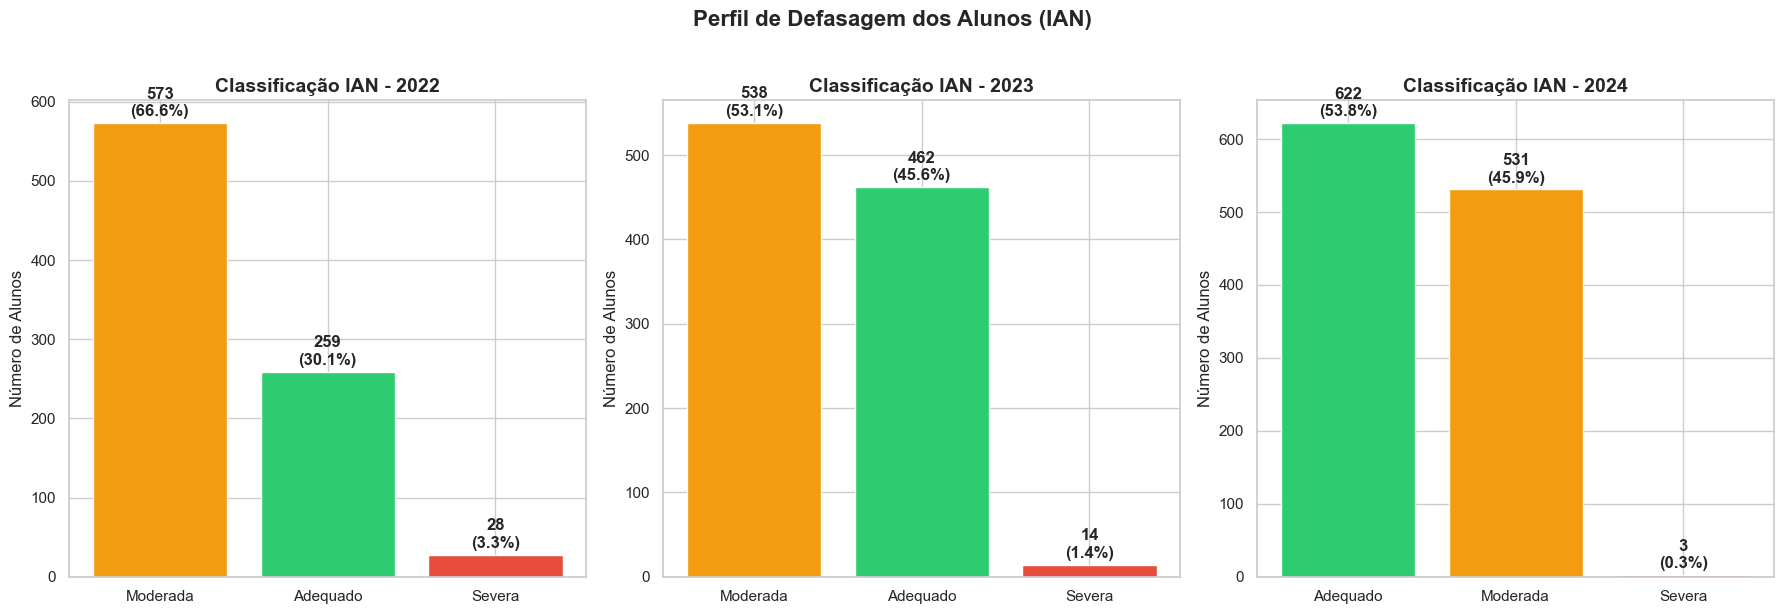

In [8]:
# Perfil de defasagem (IAN) por ano
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df_consolidado[df_consolidado['Ano'] == ano]
    ian_vals = df_ano['IAN'].dropna()

    # Classificar defasagem
    def classificar_ian(val):
        if val >= 9:
            return 'Adequado'
        elif val >= 4:
            return 'Moderada'
        else:
            return 'Severa'

    classif = ian_vals.apply(classificar_ian)
    contagem = classif.value_counts()

    cores = {'Adequado': '#2ecc71', 'Moderada': '#f39c12', 'Severa': '#e74c3c'}
    bars = axes[i].bar(contagem.index, contagem.values,
                       color=[cores.get(x, '#95a5a6') for x in contagem.index])
    axes[i].set_title(f'Classificação IAN - {ano}', fontweight='bold')
    axes[i].set_ylabel('Número de Alunos')

    # Adicionar percentuais
    total = contagem.sum()
    for bar, val in zip(bars, contagem.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                    f'{val}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Perfil de Defasagem dos Alunos (IAN)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_ian_perfil_defasagem.png', dpi=150, bbox_inches='tight')
plt.show()

Evolução do IAN por ano:
      mean  median   std  count
Ano                            
2022  6.42     5.0  2.39    860
2023  7.24     5.0  2.54   1014
2024  7.68    10.0  2.50   1156


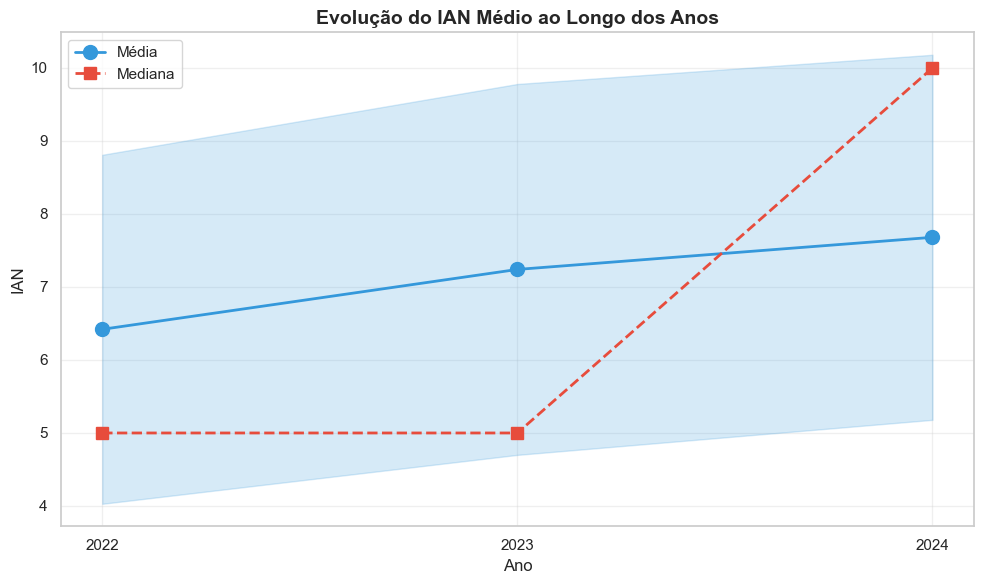

In [9]:
# Evolução do IAN médio ao longo dos anos
ian_por_ano = df_consolidado.groupby('Ano')['IAN'].agg(['mean', 'median', 'std', 'count']).round(2)
print("Evolução do IAN por ano:")
print(ian_por_ano)

fig, ax = plt.subplots(figsize=(10, 6))
anos = ian_por_ano.index
ax.plot(anos, ian_por_ano['mean'], 'o-', color='#3498db', linewidth=2, markersize=10, label='Média')
ax.plot(anos, ian_por_ano['median'], 's--', color='#e74c3c', linewidth=2, markersize=8, label='Mediana')
ax.fill_between(anos, ian_por_ano['mean'] - ian_por_ano['std'],
                ian_por_ano['mean'] + ian_por_ano['std'], alpha=0.2, color='#3498db')
ax.set_xlabel('Ano')
ax.set_ylabel('IAN')
ax.set_title('Evolução do IAN Médio ao Longo dos Anos', fontweight='bold')
ax.legend()
ax.set_xticks(anos)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/02_ian_evolucao.png', dpi=150, bbox_inches='tight')
plt.show()

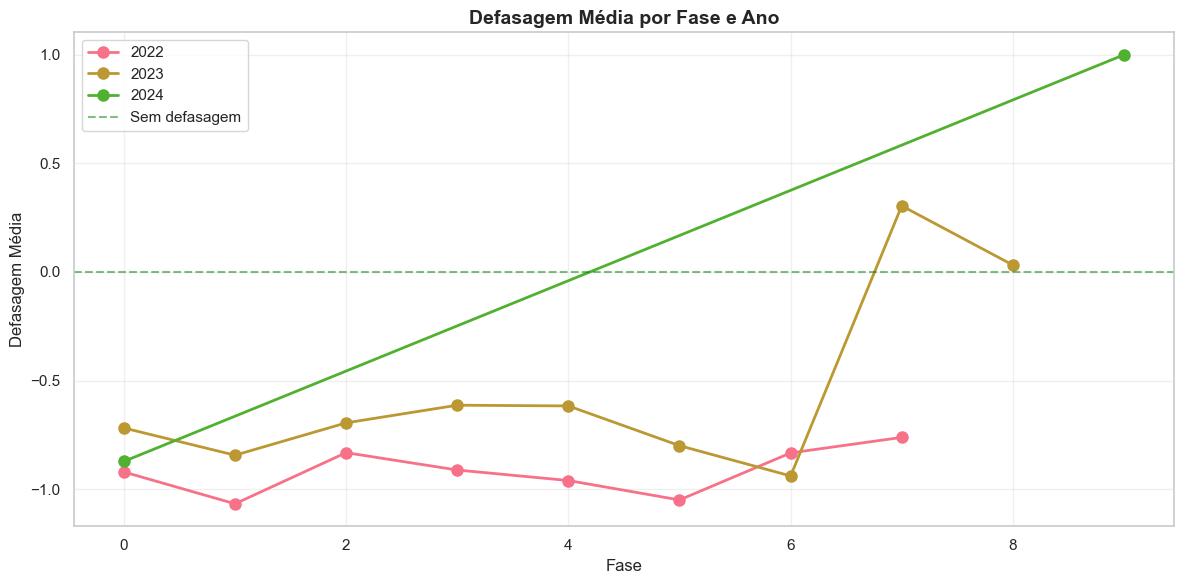

In [10]:
# Defasagem por Fase
if 'Defasagem' in df_consolidado.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    df_defas = df_consolidado.dropna(subset=['Defasagem', 'Fase'])
    df_defas_grouped = df_defas.groupby(['Ano', 'Fase'])['Defasagem'].mean().reset_index()

    for ano in [2022, 2023, 2024]:
        dados = df_defas_grouped[df_defas_grouped['Ano'] == ano]
        ax.plot(dados['Fase'], dados['Defasagem'], 'o-', label=str(ano), linewidth=2, markersize=8)

    ax.axhline(y=0, color='green', linestyle='--', alpha=0.5, label='Sem defasagem')
    ax.set_xlabel('Fase')
    ax.set_ylabel('Defasagem Média')
    ax.set_title('Defasagem Média por Fase e Ano', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../outputs/03_defasagem_por_fase.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Coluna de Defasagem não encontrada no dataset consolidado.")

### Conclusão - Pergunta 1 (IAN):
- O perfil de defasagem mostra a proporção de alunos em cada categoria (adequado, moderada, severa)
- A evolução do IAN ao longo dos anos indica se o programa está conseguindo reduzir a defasagem
- A análise por fase permite identificar onde a defasagem é mais concentrada

---
## Pergunta 2: Desempenho Acadêmico (IDA)
**O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?**

O IDA é a média das notas do aluno nas avaliações internas (Português, Matemática, Inglês).

Evolução do IDA por ano:
       mean  median   std  count
Ano                             
2022  12.14    12.0  2.77    860
2023  12.29    12.0  3.25    615
2024  12.99    12.0  3.58   1156


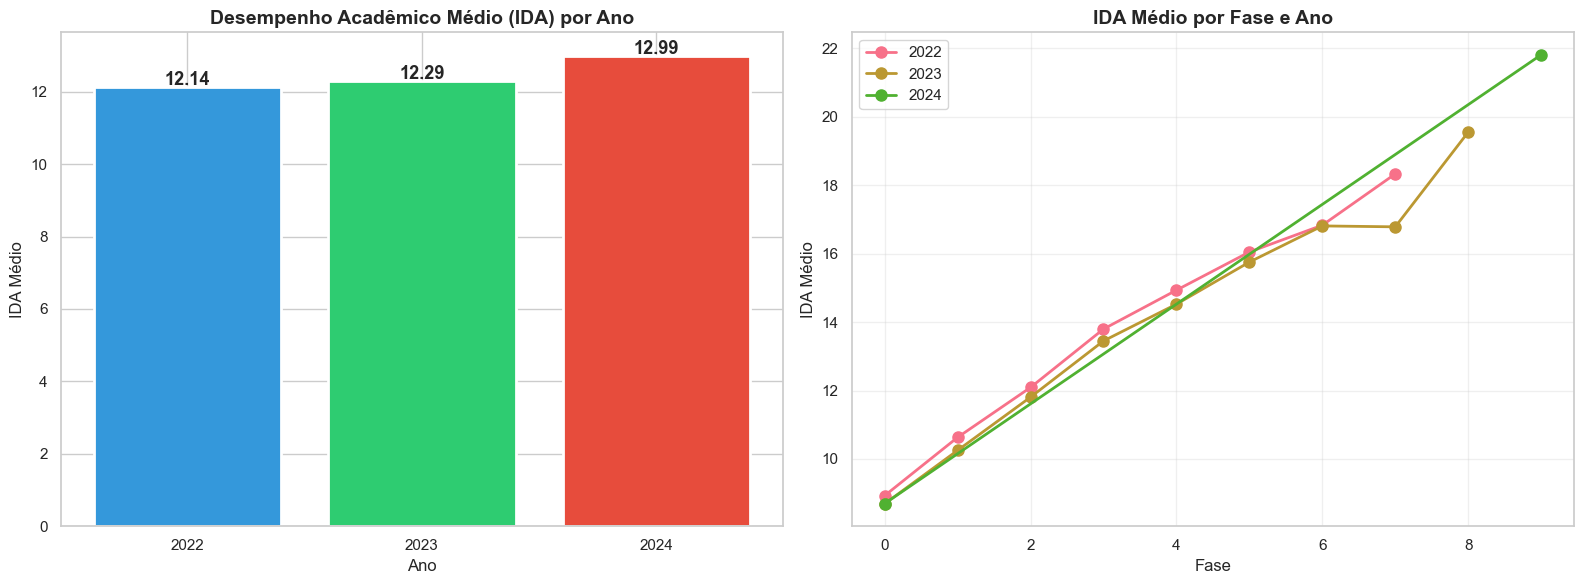

In [11]:
# Evolução do IDA por ano
ida_por_ano = df_consolidado.groupby('Ano')['IDA'].agg(['mean', 'median', 'std', 'count']).round(2)
print("Evolução do IDA por ano:")
print(ida_por_ano)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: IDA médio por ano
ax = axes[0]
ax.bar(ida_por_ano.index, ida_por_ano['mean'], color=['#3498db', '#2ecc71', '#e74c3c'],
       edgecolor='white', linewidth=2)
for i, (ano, row) in enumerate(ida_por_ano.iterrows()):
    ax.text(ano, row['mean'] + 0.05, f"{row['mean']:.2f}", ha='center', fontweight='bold', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('IDA Médio')
ax.set_title('Desempenho Acadêmico Médio (IDA) por Ano', fontweight='bold')
ax.set_xticks(ida_por_ano.index)

# Gráfico 2: IDA por Fase e Ano
ax = axes[1]
df_ida_fase = df_consolidado.dropna(subset=['IDA', 'Fase'])
df_ida_fase = df_ida_fase[df_ida_fase['Fase'].apply(lambda x: isinstance(x, (int, float)) and not np.isnan(x))]
for ano in [2022, 2023, 2024]:
    dados = df_ida_fase[df_ida_fase['Ano'] == ano].groupby('Fase')['IDA'].mean()
    ax.plot(dados.index, dados.values, 'o-', label=str(ano), linewidth=2, markersize=8)
ax.set_xlabel('Fase')
ax.set_ylabel('IDA Médio')
ax.set_title('IDA Médio por Fase e Ano', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/04_ida_evolucao.png', dpi=150, bbox_inches='tight')
plt.show()

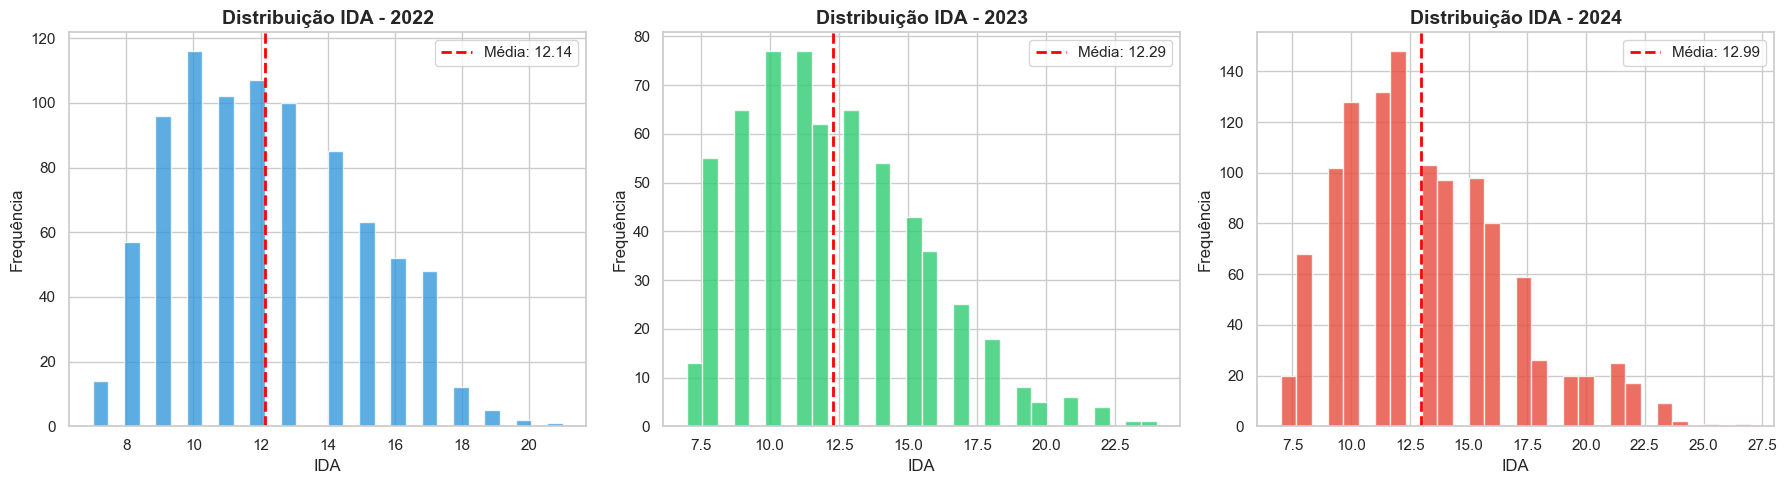

In [12]:
# Distribuição do IDA por ano
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df_consolidado[(df_consolidado['Ano'] == ano) & (df_consolidado['IDA'].notna())]
    axes[i].hist(df_ano['IDA'], bins=30, color=['#3498db', '#2ecc71', '#e74c3c'][i],
                 edgecolor='white', alpha=0.8)
    axes[i].axvline(df_ano['IDA'].mean(), color='red', linestyle='--', linewidth=2, label=f"Média: {df_ano['IDA'].mean():.2f}")
    axes[i].set_title(f'Distribuição IDA - {ano}', fontweight='bold')
    axes[i].set_xlabel('IDA')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()
plt.tight_layout()
plt.savefig('../outputs/05_ida_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão - Pergunta 2 (IDA):
- Análise da tendência do desempenho acadêmico ao longo dos anos
- Comparação por fase mostra em quais níveis o desempenho é maior/menor
- A distribuição revela se há concentração ou dispersão das notas

---
## Pergunta 3: Engajamento (IEG)
**O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?**

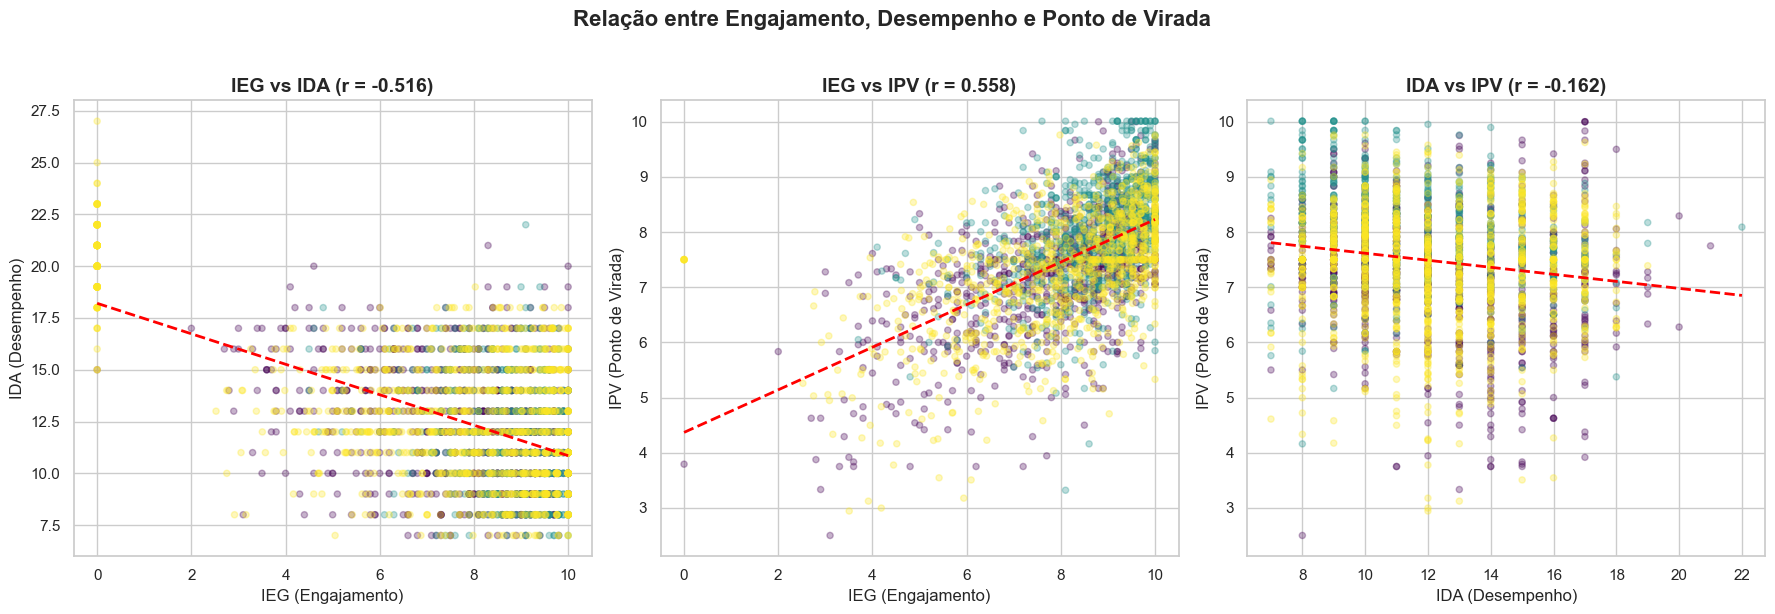

In [13]:
# Correlação IEG x IDA x IPV
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# IEG vs IDA
df_corr = df_consolidado.dropna(subset=['IEG', 'IDA'])
axes[0].scatter(df_corr['IEG'], df_corr['IDA'], alpha=0.3, c=df_corr['Ano'], cmap='viridis', s=20)
z = np.polyfit(df_corr['IEG'].values, df_corr['IDA'].values, 1)
p = np.poly1d(z)
x_line = np.linspace(df_corr['IEG'].min(), df_corr['IEG'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2)
corr_val = df_corr['IEG'].corr(df_corr['IDA'])
axes[0].set_title(f'IEG vs IDA (r = {corr_val:.3f})', fontweight='bold')
axes[0].set_xlabel('IEG (Engajamento)')
axes[0].set_ylabel('IDA (Desempenho)')

# IEG vs IPV
df_corr2 = df_consolidado.dropna(subset=['IEG', 'IPV'])
axes[1].scatter(df_corr2['IEG'], df_corr2['IPV'], alpha=0.3, c=df_corr2['Ano'], cmap='viridis', s=20)
z2 = np.polyfit(df_corr2['IEG'].values, df_corr2['IPV'].values, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_corr2['IEG'].min(), df_corr2['IEG'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), 'r--', linewidth=2)
corr_val2 = df_corr2['IEG'].corr(df_corr2['IPV'])
axes[1].set_title(f'IEG vs IPV (r = {corr_val2:.3f})', fontweight='bold')
axes[1].set_xlabel('IEG (Engajamento)')
axes[1].set_ylabel('IPV (Ponto de Virada)')

# IDA vs IPV
df_corr3 = df_consolidado.dropna(subset=['IDA', 'IPV'])
axes[2].scatter(df_corr3['IDA'], df_corr3['IPV'], alpha=0.3, c=df_corr3['Ano'], cmap='viridis', s=20)
z3 = np.polyfit(df_corr3['IDA'].values, df_corr3['IPV'].values, 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df_corr3['IDA'].min(), df_corr3['IDA'].max(), 100)
axes[2].plot(x_line3, p3(x_line3), 'r--', linewidth=2)
corr_val3 = df_corr3['IDA'].corr(df_corr3['IPV'])
axes[2].set_title(f'IDA vs IPV (r = {corr_val3:.3f})', fontweight='bold')
axes[2].set_xlabel('IDA (Desempenho)')
axes[2].set_ylabel('IPV (Ponto de Virada)')

plt.suptitle('Relação entre Engajamento, Desempenho e Ponto de Virada', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/06_ieg_correlacoes.png', dpi=150, bbox_inches='tight')
plt.show()

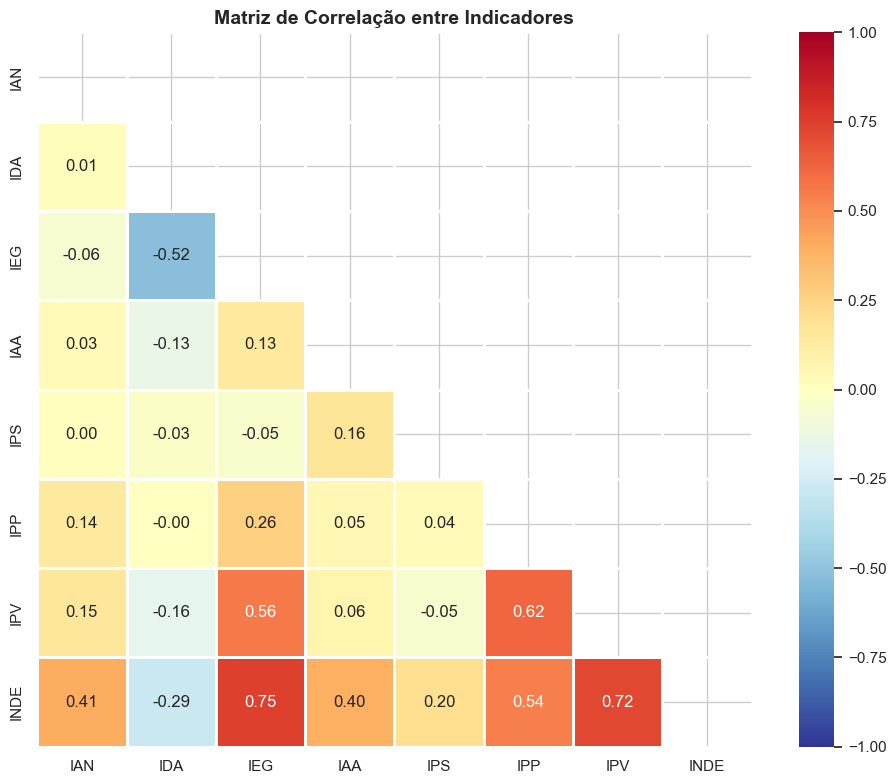

In [14]:
# Matriz de correlação dos indicadores
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_consolidado[['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'INDE']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True, linewidths=1)
ax.set_title('Matriz de Correlação entre Indicadores', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/07_matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão - Pergunta 3 (IEG):
- A correlação entre IEG e IDA mostra o quão forte é a relação entre engajamento e desempenho acadêmico
- A relação IEG-IPV indica se alunos mais engajados têm maior probabilidade de atingir o ponto de virada
- A matriz de correlação revela as inter-relações entre todos os indicadores

---
## Pergunta 4: Autoavaliação (IAA)
**As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?**

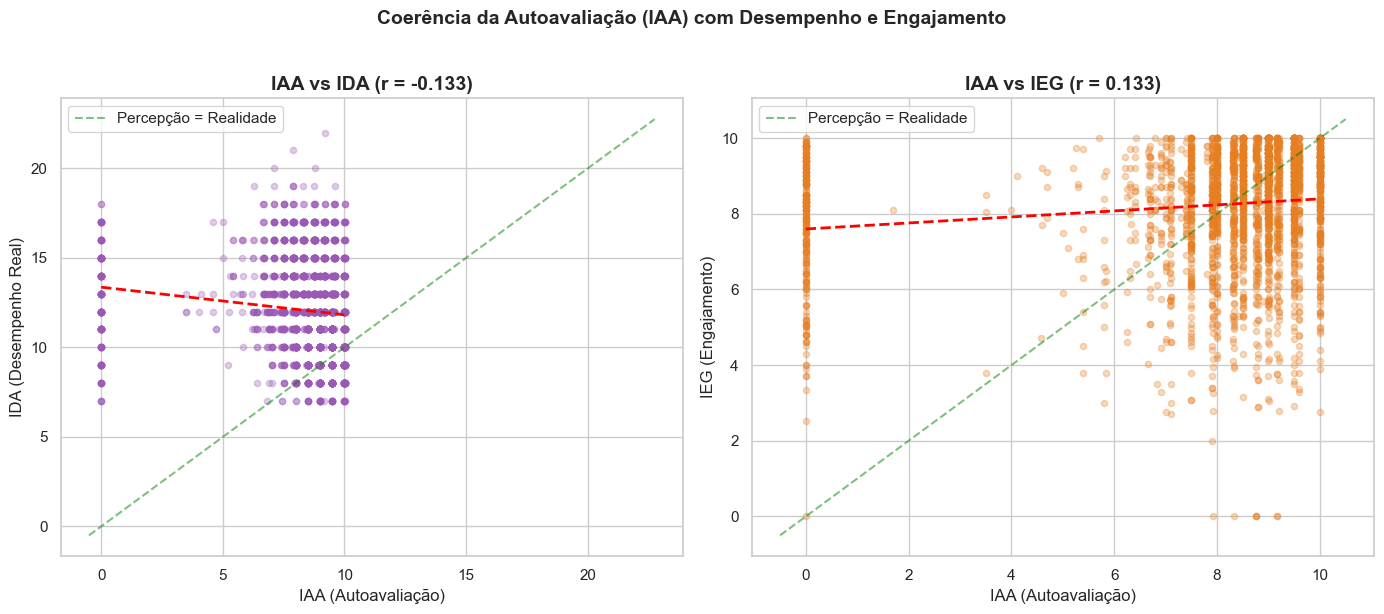

In [15]:
# IAA vs IDA e IEG
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# IAA vs IDA
df_aa = df_consolidado.dropna(subset=['IAA', 'IDA'])
axes[0].scatter(df_aa['IAA'], df_aa['IDA'], alpha=0.3, color='#9b59b6', s=20)
z = np.polyfit(df_aa['IAA'].values, df_aa['IDA'].values, 1)
p = np.poly1d(z)
x_line = np.linspace(df_aa['IAA'].min(), df_aa['IAA'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2)
corr = df_aa['IAA'].corr(df_aa['IDA'])
axes[0].set_title(f'IAA vs IDA (r = {corr:.3f})', fontweight='bold')
axes[0].set_xlabel('IAA (Autoavaliação)')
axes[0].set_ylabel('IDA (Desempenho Real)')
# Linha de referência (percepção = realidade)
lims = [min(axes[0].get_xlim()[0], axes[0].get_ylim()[0]), max(axes[0].get_xlim()[1], axes[0].get_ylim()[1])]
axes[0].plot(lims, lims, 'g--', alpha=0.5, label='Percepção = Realidade')
axes[0].legend()

# IAA vs IEG
df_aa2 = df_consolidado.dropna(subset=['IAA', 'IEG'])
axes[1].scatter(df_aa2['IAA'], df_aa2['IEG'], alpha=0.3, color='#e67e22', s=20)
z2 = np.polyfit(df_aa2['IAA'].values, df_aa2['IEG'].values, 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_aa2['IAA'].min(), df_aa2['IAA'].max(), 100)
axes[1].plot(x_line2, p2(x_line2), 'r--', linewidth=2)
corr2 = df_aa2['IAA'].corr(df_aa2['IEG'])
axes[1].set_title(f'IAA vs IEG (r = {corr2:.3f})', fontweight='bold')
axes[1].set_xlabel('IAA (Autoavaliação)')
axes[1].set_ylabel('IEG (Engajamento)')
lims = [min(axes[1].get_xlim()[0], axes[1].get_ylim()[0]), max(axes[1].get_xlim()[1], axes[1].get_ylim()[1])]
axes[1].plot(lims, lims, 'g--', alpha=0.5, label='Percepção = Realidade')
axes[1].legend()

plt.suptitle('Coerência da Autoavaliação (IAA) com Desempenho e Engajamento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/08_iaa_coerencia.png', dpi=150, bbox_inches='tight')
plt.show()

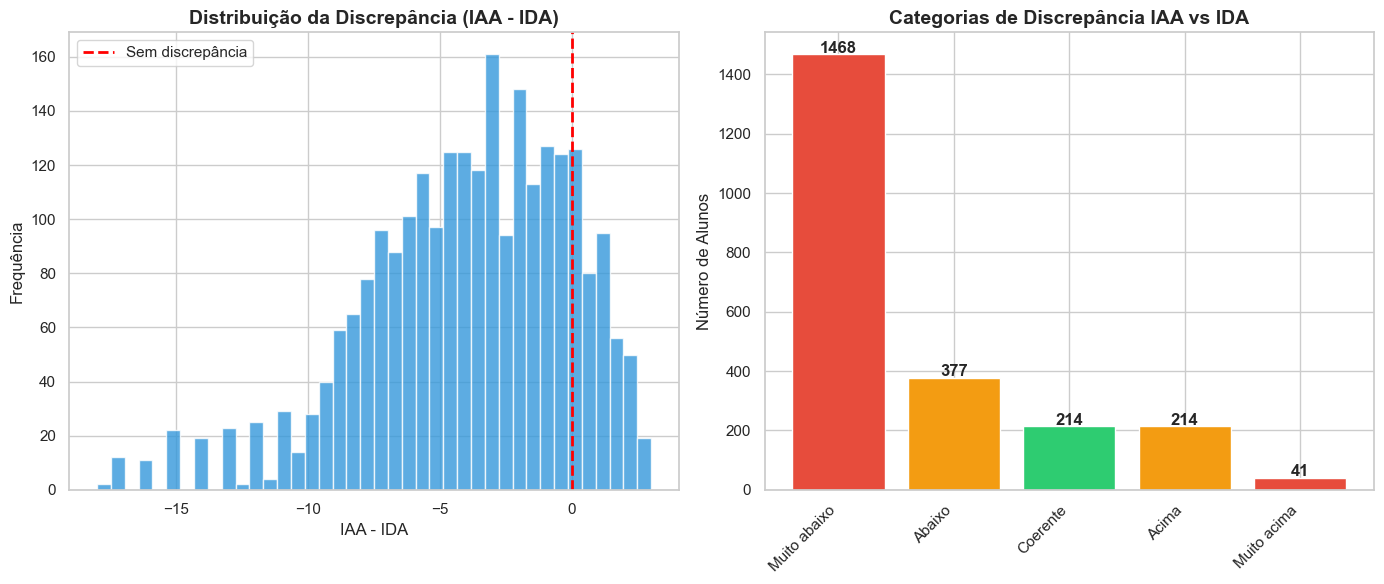


Discrepância média: -4.02
Alunos com percepção coerente: 214 (8.6%)


In [16]:
# Análise de discrepância IAA vs IDA
df_disc = df_consolidado.dropna(subset=['IAA', 'IDA']).copy()
df_disc['Discrepancia'] = df_disc['IAA'] - df_disc['IDA']
df_disc['Categoria'] = pd.cut(df_disc['Discrepancia'],
                               bins=[-10, -2, -0.5, 0.5, 2, 10],
                               labels=['Muito abaixo', 'Abaixo', 'Coerente', 'Acima', 'Muito acima'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribuição da discrepância
axes[0].hist(df_disc['Discrepancia'], bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Sem discrepância')
axes[0].set_title('Distribuição da Discrepância (IAA - IDA)', fontweight='bold')
axes[0].set_xlabel('IAA - IDA')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Proporção por categoria
cat_count = df_disc['Categoria'].value_counts().sort_index()
cores_cat = ['#e74c3c', '#f39c12', '#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(range(len(cat_count)), cat_count.values, color=cores_cat, edgecolor='white')
axes[1].set_xticks(range(len(cat_count)))
axes[1].set_xticklabels(cat_count.index, rotation=45, ha='right')
axes[1].set_title('Categorias de Discrepância IAA vs IDA', fontweight='bold')
axes[1].set_ylabel('Número de Alunos')
for i, v in enumerate(cat_count.values):
    axes[1].text(i, v + 5, f'{v}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/09_iaa_discrepancia.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDiscrepância média: {df_disc['Discrepancia'].mean():.2f}")
print(f"Alunos com percepção coerente: {(df_disc['Categoria'] == 'Coerente').sum()} ({(df_disc['Categoria'] == 'Coerente').mean()*100:.1f}%)")

### Conclusão - Pergunta 4 (IAA):
- A análise mostra se os alunos têm uma percepção realista de si mesmos
- Discrepâncias positivas (IAA > IDA) indicam superestimação
- Discrepâncias negativas (IAA < IDA) indicam subestimação
- Isso pode guiar intervenções psicopedagógicas focadas na autopercepção

---
## Pergunta 5: Aspectos Psicossociais (IPS)
**Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?**

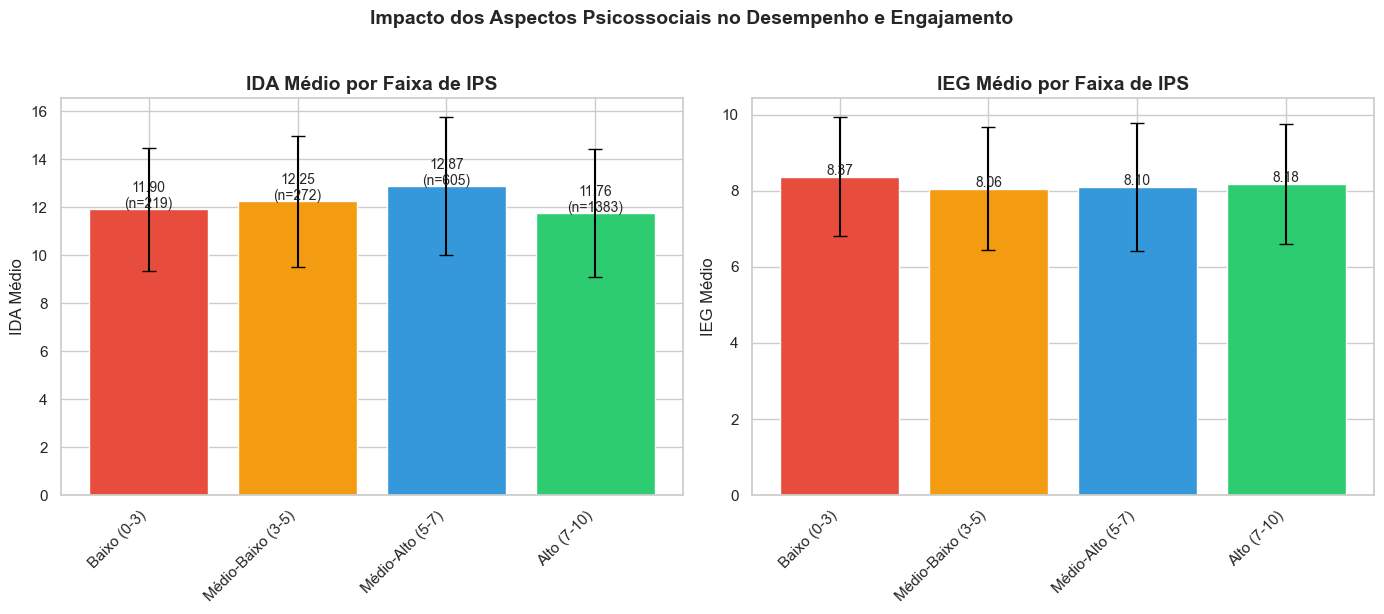

In [17]:
# Relação IPS com IDA e IEG por faixas de IPS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_ips = df_consolidado.dropna(subset=['IPS', 'IDA', 'IEG']).copy()
df_ips['Faixa_IPS'] = pd.cut(df_ips['IPS'], bins=[0, 3, 5, 7, 10],
                              labels=['Baixo (0-3)', 'Médio-Baixo (3-5)', 'Médio-Alto (5-7)', 'Alto (7-10)'])

# IDA por faixa de IPS
faixa_ida = df_ips.groupby('Faixa_IPS')['IDA'].agg(['mean', 'std', 'count'])
axes[0].bar(range(len(faixa_ida)), faixa_ida['mean'],
            yerr=faixa_ida['std'], capsize=5,
            color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'], edgecolor='white')
axes[0].set_xticks(range(len(faixa_ida)))
axes[0].set_xticklabels(faixa_ida.index, rotation=45, ha='right')
axes[0].set_title('IDA Médio por Faixa de IPS', fontweight='bold')
axes[0].set_ylabel('IDA Médio')
for i, v in enumerate(faixa_ida['mean']):
    axes[0].text(i, v + 0.05, f'{v:.2f}\n(n={int(faixa_ida["count"].iloc[i])})', ha='center', fontsize=10)

# IEG por faixa de IPS
faixa_ieg = df_ips.groupby('Faixa_IPS')['IEG'].agg(['mean', 'std', 'count'])
axes[1].bar(range(len(faixa_ieg)), faixa_ieg['mean'],
            yerr=faixa_ieg['std'], capsize=5,
            color=['#e74c3c', '#f39c12', '#3498db', '#2ecc71'], edgecolor='white')
axes[1].set_xticks(range(len(faixa_ieg)))
axes[1].set_xticklabels(faixa_ieg.index, rotation=45, ha='right')
axes[1].set_title('IEG Médio por Faixa de IPS', fontweight='bold')
axes[1].set_ylabel('IEG Médio')
for i, v in enumerate(faixa_ieg['mean']):
    axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('Impacto dos Aspectos Psicossociais no Desempenho e Engajamento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/10_ips_impacto.png', dpi=150, bbox_inches='tight')
plt.show()

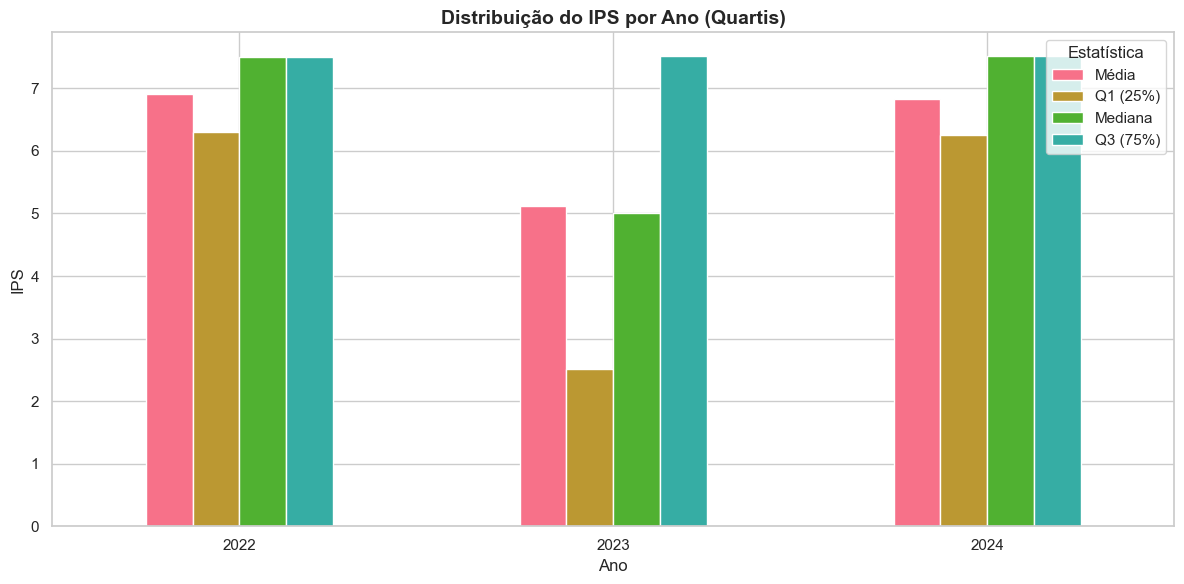


Teste Mann-Whitney: IDA de alunos com IPS baixo vs alto
  IDA médio (IPS baixo): 12.56
  IDA médio (IPS alto): 11.74
  p-valor: 1.000000
  Diferença não significativa


In [18]:
# Análise de padrões de IPS ao longo dos anos
fig, ax = plt.subplots(figsize=(12, 6))
ips_ano = df_consolidado.groupby('Ano')['IPS'].describe()[['mean', '25%', '50%', '75%']]
ips_ano.columns = ['Média', 'Q1 (25%)', 'Mediana', 'Q3 (75%)']
ips_ano.plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Distribuição do IPS por Ano (Quartis)', fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('IPS')
ax.legend(title='Estatística')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('../outputs/11_ips_por_ano.png', dpi=150, bbox_inches='tight')
plt.show()

# Teste estatístico: IPS baixo está associado a IDA baixo?
df_test = df_consolidado.dropna(subset=['IPS', 'IDA'])
ips_baixo = df_test[df_test['IPS'] < df_test['IPS'].median()]['IDA']
ips_alto = df_test[df_test['IPS'] >= df_test['IPS'].median()]['IDA']
stat, pval = stats.mannwhitneyu(ips_baixo, ips_alto, alternative='less')
print(f"\nTeste Mann-Whitney: IDA de alunos com IPS baixo vs alto")
print(f"  IDA médio (IPS baixo): {ips_baixo.mean():.2f}")
print(f"  IDA médio (IPS alto): {ips_alto.mean():.2f}")
print(f"  p-valor: {pval:.6f}")
print(f"  {'Diferença significativa (p < 0.05)' if pval < 0.05 else 'Diferença não significativa'}")

### Conclusão - Pergunta 5 (IPS):
- A análise por faixas mostra se alunos com IPS mais baixo tendem a ter pior desempenho
- Padrões psicossociais negativos podem servir como sinais de alerta precoce
- Isso permite intervenções preventivas pela equipe de psicologia

---
## Pergunta 6: Aspectos Psicopedagógicos (IPP)
**As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?**

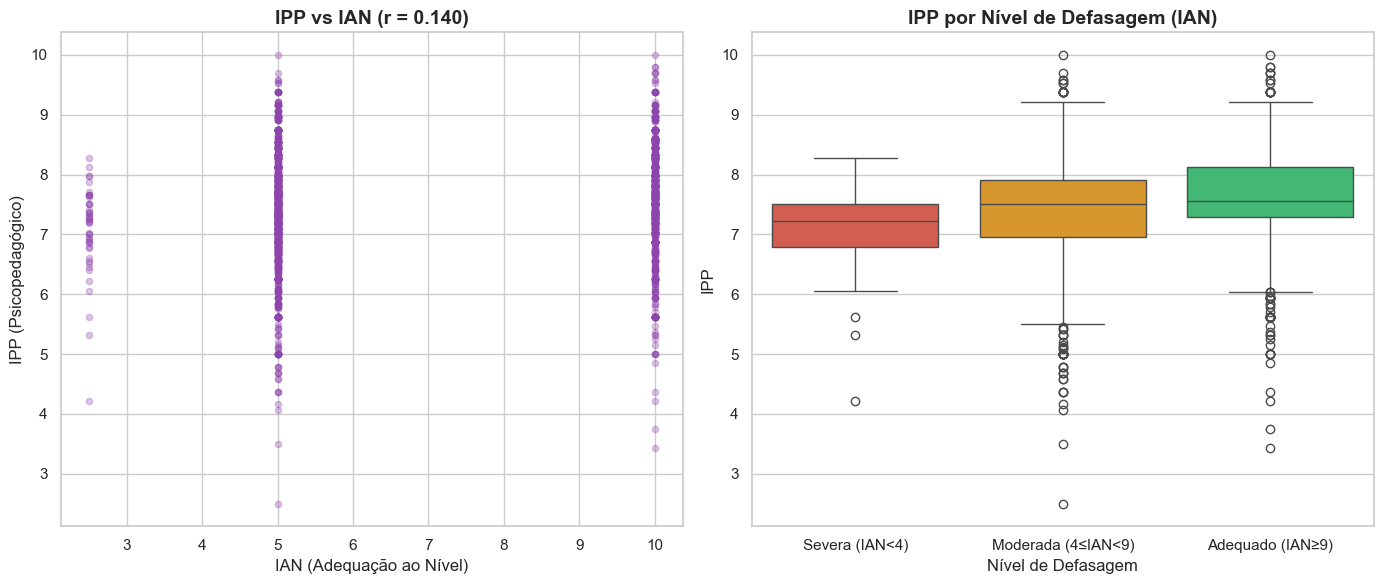


IPP médio por nível de IAN:
  Severa (IAN<4): IPP médio = 7.07 (n=45)
  Moderada (4≤IAN<9): IPP médio = 7.41 (n=1642)
  Adequado (IAN≥9): IPP médio = 7.63 (n=1343)


In [19]:
# IPP vs IAN
df_pp = df_consolidado.dropna(subset=['IPP', 'IAN']).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot IPP vs IAN
axes[0].scatter(df_pp['IAN'], df_pp['IPP'], alpha=0.3, color='#8e44ad', s=20)
corr_pp_ian = df_pp['IPP'].corr(df_pp['IAN'])
axes[0].set_title(f'IPP vs IAN (r = {corr_pp_ian:.3f})', fontweight='bold')
axes[0].set_xlabel('IAN (Adequação ao Nível)')
axes[0].set_ylabel('IPP (Psicopedagógico)')

# Boxplot IPP por nível de IAN
def classificar_ian_nivel(val):
    if val >= 9:
        return 'Adequado (IAN≥9)'
    elif val >= 4:
        return 'Moderada (4≤IAN<9)'
    else:
        return 'Severa (IAN<4)'

df_pp['IAN_Nivel'] = df_pp['IAN'].apply(classificar_ian_nivel)
ordem = ['Severa (IAN<4)', 'Moderada (4≤IAN<9)', 'Adequado (IAN≥9)']
df_pp_plot = df_pp[df_pp['IAN_Nivel'].isin(ordem)]

sns.boxplot(data=df_pp_plot, x='IAN_Nivel', y='IPP', order=ordem,
            palette=['#e74c3c', '#f39c12', '#2ecc71'], ax=axes[1])
axes[1].set_title('IPP por Nível de Defasagem (IAN)', fontweight='bold')
axes[1].set_xlabel('Nível de Defasagem')
axes[1].set_ylabel('IPP')

plt.tight_layout()
plt.savefig('../outputs/12_ipp_vs_ian.png', dpi=150, bbox_inches='tight')
plt.show()

# Análise de concordância/discordância
print("\nIPP médio por nível de IAN:")
for nivel in ordem:
    dados = df_pp[df_pp['IAN_Nivel'] == nivel]['IPP']
    print(f"  {nivel}: IPP médio = {dados.mean():.2f} (n={len(dados)})")

### Conclusão - Pergunta 6 (IPP):
- Se IPP é alto para alunos com IAN baixo, a avaliação psicopedagógica **contradiz** a defasagem
- Se IPP é baixo para alunos com IAN baixo, a avaliação **confirma** a defasagem
- Divergências podem indicar alunos com potencial não aproveitado ou defasagens por outros fatores

---
## Pergunta 7: Ponto de Virada (IPV)
**Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?**

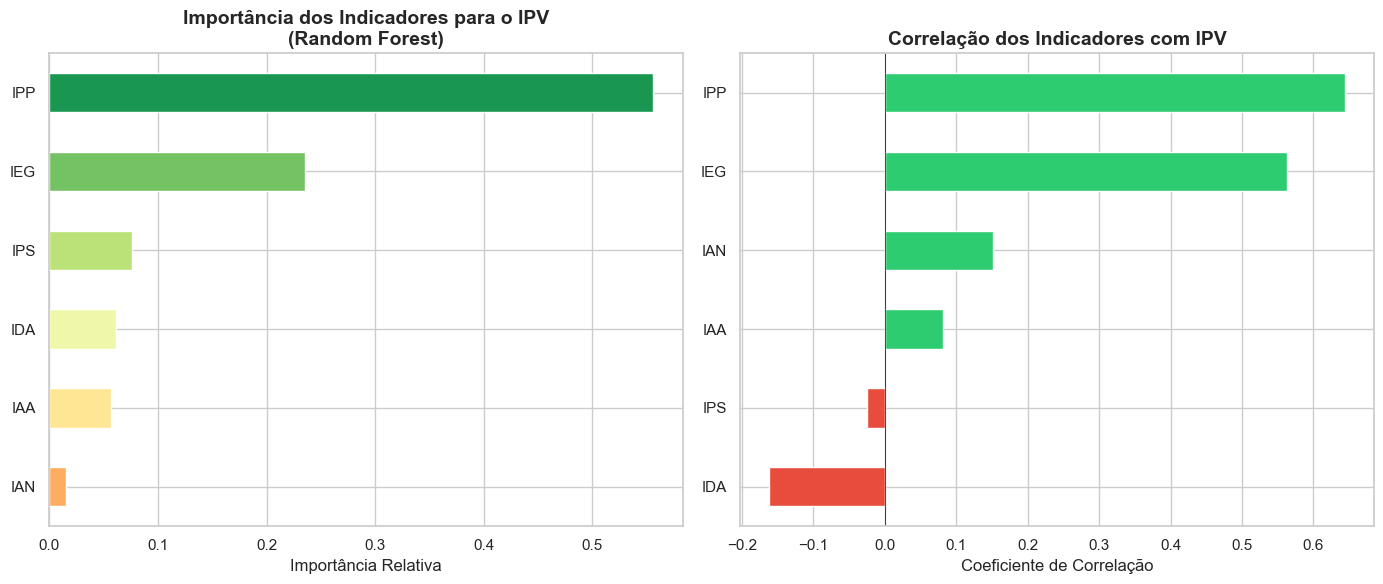

R² do modelo: 0.853


In [20]:
# Análise de importância dos indicadores para o IPV
from sklearn.ensemble import RandomForestRegressor

df_ipv = df_consolidado.dropna(subset=['IPV', 'IDA', 'IEG', 'IAA', 'IPS']).copy()
features_ipv = ['IDA', 'IEG', 'IAA', 'IPS', 'IAN']
# Incluir IPP se disponível
if df_ipv['IPP'].notna().sum() > 100:
    features_ipv.append('IPP')

df_ipv_clean = df_ipv.dropna(subset=features_ipv + ['IPV'])

if len(df_ipv_clean) > 50:
    X = df_ipv_clean[features_ipv]
    y = df_ipv_clean['IPV']

    rf = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
    rf.fit(X, y)

    importances = pd.Series(rf.feature_importances_, index=features_ipv).sort_values(ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Feature importance
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances)))
    importances.plot(kind='barh', ax=axes[0], color=colors)
    axes[0].set_title('Importância dos Indicadores para o IPV\n(Random Forest)', fontweight='bold')
    axes[0].set_xlabel('Importância Relativa')

    # Correlações com IPV
    corr_ipv = df_ipv_clean[features_ipv + ['IPV']].corr()['IPV'].drop('IPV').sort_values()
    corr_ipv.plot(kind='barh', ax=axes[1], color=['#e74c3c' if v < 0 else '#2ecc71' for v in corr_ipv])
    axes[1].set_title('Correlação dos Indicadores com IPV', fontweight='bold')
    axes[1].set_xlabel('Coeficiente de Correlação')
    axes[1].axvline(0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('../outputs/13_ipv_importancia.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"R² do modelo: {rf.score(X, y):.3f}")
else:
    print(f"Dados insuficientes para análise de IPV: {len(df_ipv_clean)} registros")

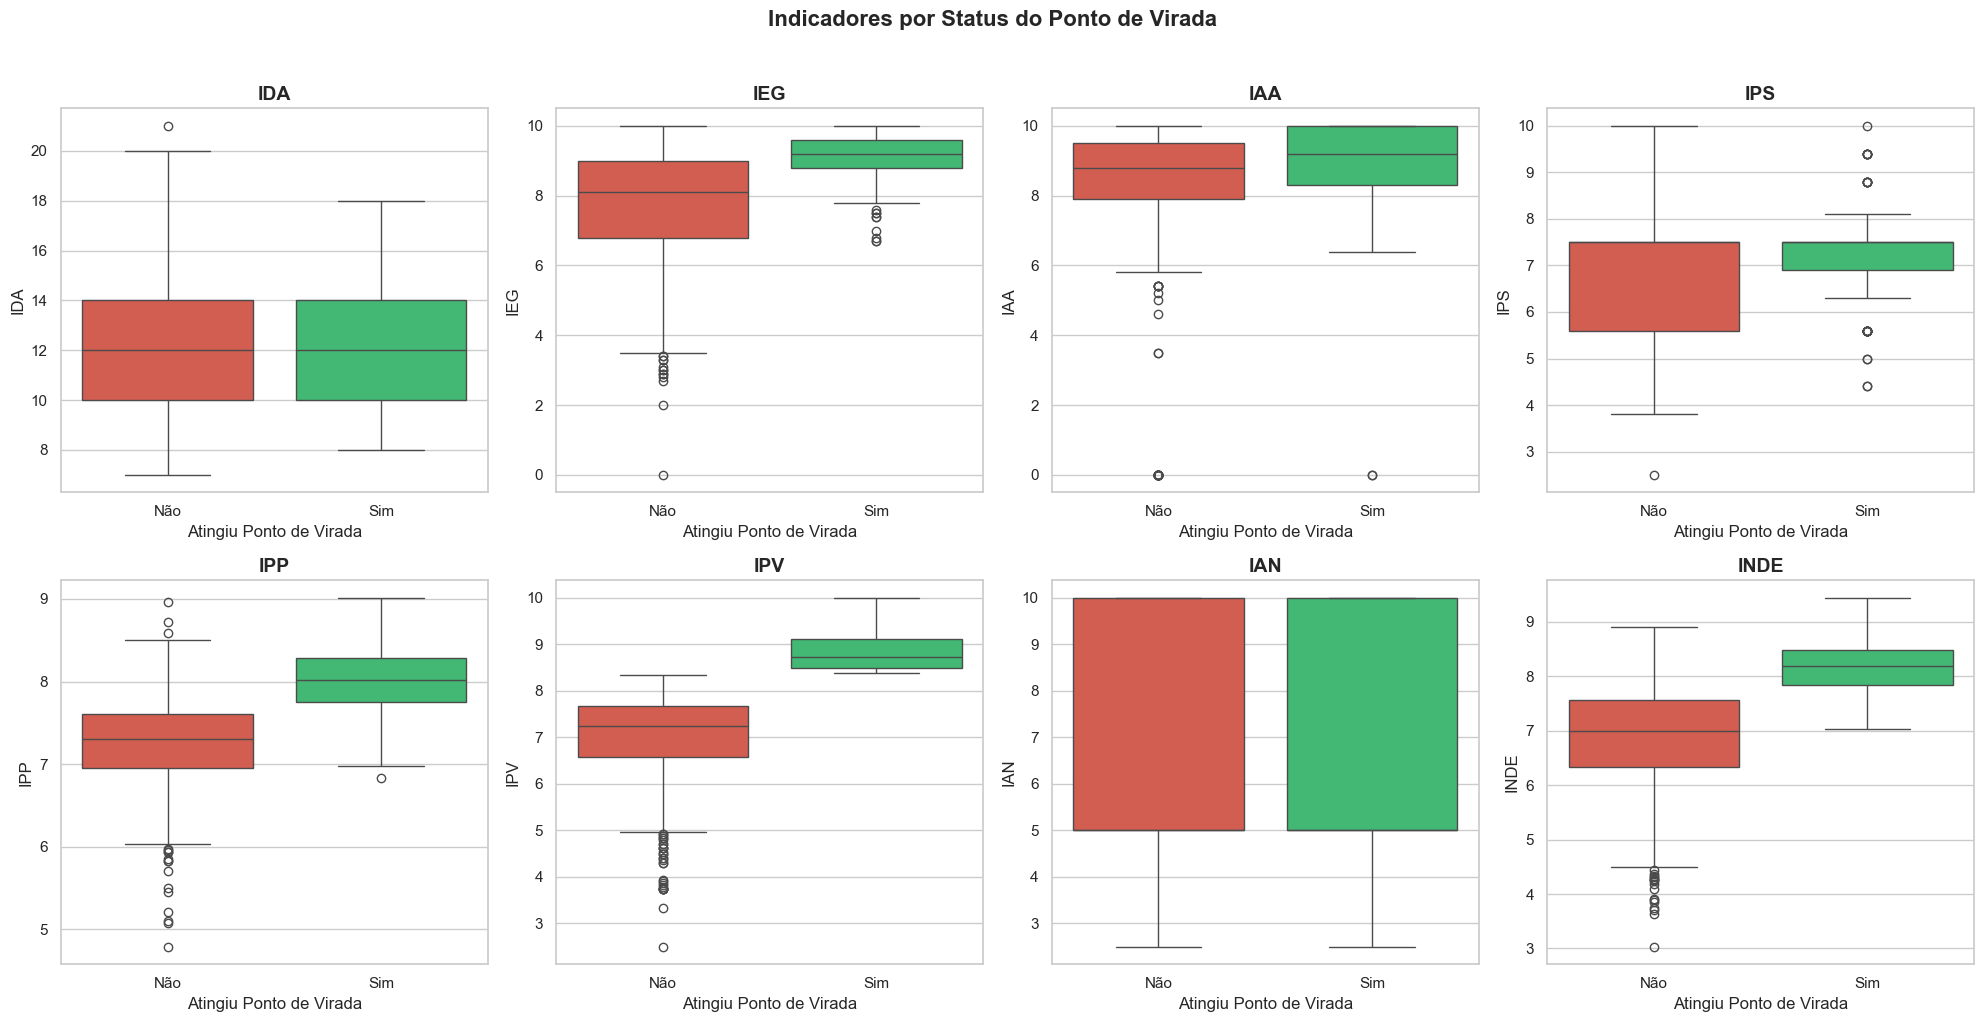

In [21]:
# Análise do Ponto de Virada (booleano) vs indicadores
if 'Ponto_Virada' in df_consolidado.columns:
    df_pv = df_consolidado.dropna(subset=['Ponto_Virada']).copy()
    # Converter para string para compatibilidade com seaborn
    df_pv['PV_Bool'] = df_pv['Ponto_Virada'].apply(
        lambda x: 'Sim' if str(x).strip().lower() in ['sim', 'true', '1', 'yes', 's'] else 'Não'
    )

    indicadores_comp = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN', 'INDE']

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, ind in enumerate(indicadores_comp):
        if i < len(axes):
            df_plot = df_pv.dropna(subset=[ind])
            if len(df_plot) > 10:
                sns.boxplot(data=df_plot, x='PV_Bool', y=ind, ax=axes[i],
                           palette={'Sim': '#2ecc71', 'Não': '#e74c3c'})
                axes[i].set_title(f'{ind}', fontweight='bold')
                axes[i].set_xlabel('Atingiu Ponto de Virada')

    plt.suptitle('Indicadores por Status do Ponto de Virada', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../outputs/14_ponto_virada_indicadores.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Coluna Ponto_Virada não encontrada. Análise baseada apenas no IPV numérico.")

### Conclusão - Pergunta 7 (IPV):
- Os indicadores que mais influenciam o IPV identificam os fatores-chave para o "ponto de virada" dos alunos
- Isso permite focar recursos nos aspectos que mais impactam a transformação educacional

---
## Pergunta 8: Multidimensionalidade dos Indicadores
**Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?**

Fórmula INDE (Fases 0-7): `INDE = IAN×0.1 + IDA×0.2 + IEG×0.2 + IAA×0.1 + IPS×0.1 + IPP×0.1 + IPV×0.2`

Contribuição de cada indicador para o INDE:
     Peso  Média  Contribuição_Média  Contribuição_%
IAN   0.1   7.01                0.70            8.30
IDA   0.2  12.09                2.42           28.63
IEG   0.2   8.23                1.65           19.49
IAA   0.1   7.93                0.79            9.38
IPS   0.1   6.30                0.63            7.46
IPP   0.1   7.50                0.75            8.87
IPV   0.2   7.55                1.51           17.87


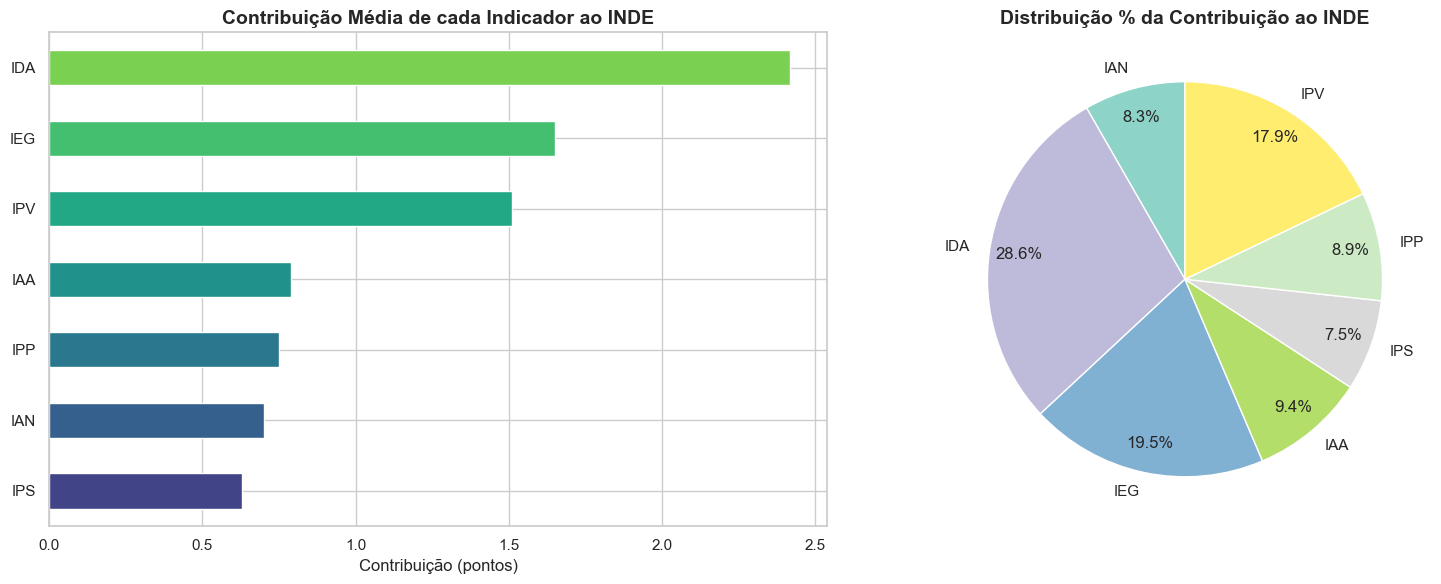

In [22]:
# Contribuição de cada indicador para o INDE
df_inde = df_consolidado.dropna(subset=['INDE']).copy()

# Calcular contribuição ponderada (pesos da fórmula INDE Fases 0-7)
pesos = {'IAN': 0.1, 'IDA': 0.2, 'IEG': 0.2, 'IAA': 0.1, 'IPS': 0.1, 'IPP': 0.1, 'IPV': 0.2}

contribuicoes = {}
for ind, peso in pesos.items():
    valores = df_inde[ind].dropna()
    contribuicoes[ind] = {
        'Peso': peso,
        'Média': valores.mean(),
        'Contribuição_Média': valores.mean() * peso,
        'Contribuição_%': 0  # calculado depois
    }

total_contrib = sum(v['Contribuição_Média'] for v in contribuicoes.values())
for ind in contribuicoes:
    contribuicoes[ind]['Contribuição_%'] = contribuicoes[ind]['Contribuição_Média'] / total_contrib * 100

contrib_df = pd.DataFrame(contribuicoes).T.round(2)
print("Contribuição de cada indicador para o INDE:")
print(contrib_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de contribuição absoluta
contrib_abs = contrib_df['Contribuição_Média'].sort_values(ascending=True)
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(contrib_abs)))
contrib_abs.plot(kind='barh', ax=axes[0], color=colors)
axes[0].set_title('Contribuição Média de cada Indicador ao INDE', fontweight='bold')
axes[0].set_xlabel('Contribuição (pontos)')

# Gráfico de pizza da contribuição percentual
contrib_pct = contrib_df['Contribuição_%']
axes[1].pie(contrib_pct, labels=contrib_pct.index, autopct='%1.1f%%',
            colors=plt.cm.Set3(np.linspace(0, 1, len(contrib_pct))),
            startangle=90, pctdistance=0.85)
axes[1].set_title('Distribuição % da Contribuição ao INDE', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/15_contribuicao_inde.png', dpi=150, bbox_inches='tight')
plt.show()

Perfil médio de cada cluster:
           IDA   IEG   IAA   IPS  INDE
Cluster                               
0        12.55  7.54  0.06  5.75  6.11
1        10.31  8.87  8.88  7.30  7.78
2        14.70  7.20  8.46  6.89  6.86
3        11.38  8.51  8.64  3.43  7.17


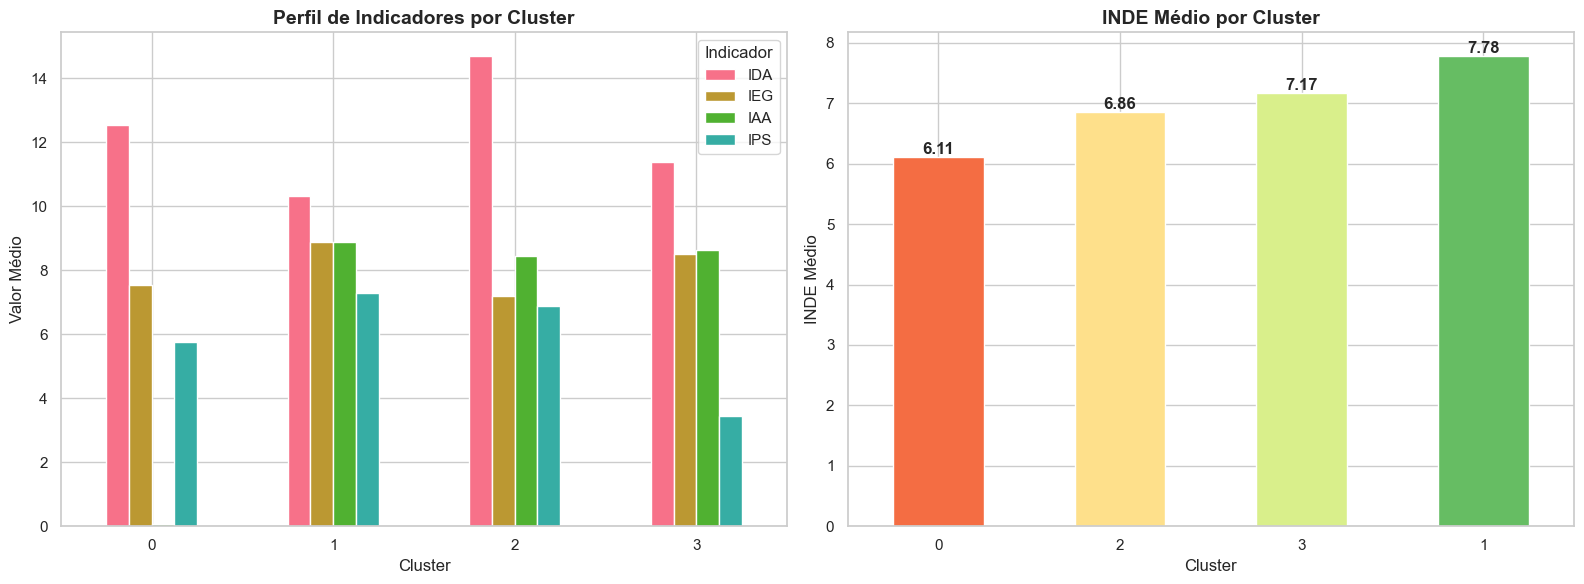

In [23]:
# Análise de clusters de perfis de alunos
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

indicadores_cluster = ['IDA', 'IEG', 'IAA', 'IPS']
df_cluster = df_consolidado.dropna(subset=indicadores_cluster + ['INDE']).copy()

if len(df_cluster) > 100:
    X_cluster = df_cluster[indicadores_cluster]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    # K-Means com 4 clusters
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df_cluster['Cluster'] = kmeans.fit_predict(X_scaled)

    # Perfil de cada cluster
    print("Perfil médio de cada cluster:")
    perfil = df_cluster.groupby('Cluster')[indicadores_cluster + ['INDE']].mean().round(2)
    print(perfil)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Radar chart simplificado como bar chart
    perfil_norm = perfil[indicadores_cluster]
    perfil_norm.plot(kind='bar', ax=axes[0], edgecolor='white')
    axes[0].set_title('Perfil de Indicadores por Cluster', fontweight='bold')
    axes[0].set_xlabel('Cluster')
    axes[0].set_ylabel('Valor Médio')
    axes[0].legend(title='Indicador')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

    # INDE por cluster
    inde_cluster = df_cluster.groupby('Cluster')['INDE'].mean().sort_values()
    inde_cluster.plot(kind='bar', ax=axes[1], color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, 4)), edgecolor='white')
    axes[1].set_title('INDE Médio por Cluster', fontweight='bold')
    axes[1].set_xlabel('Cluster')
    axes[1].set_ylabel('INDE Médio')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    for i, v in enumerate(inde_cluster):
        axes[1].text(i, v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('../outputs/16_clusters_perfil.png', dpi=150, bbox_inches='tight')
    plt.show()

### Conclusão - Pergunta 8:
- IDA e IEG são os maiores contribuintes ao INDE (peso 0.2 cada), junto com IPV
- A análise de clusters identifica perfis distintos de alunos
- Combinações onde IDA + IEG são altos tendem a elevar significativamente o INDE

---
## Pergunta 9: Previsão de Risco com Machine Learning
**Ver notebook dedicado: `02_modelo_preditivo.ipynb`**

O modelo preditivo completo está no notebook separado, incluindo:
- Feature engineering
- Separação treino/teste
- Modelagem preditiva (Random Forest, XGBoost, Logistic Regression)
- Avaliação dos resultados

---
## Pergunta 10: Efetividade do Programa
**Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio)?**

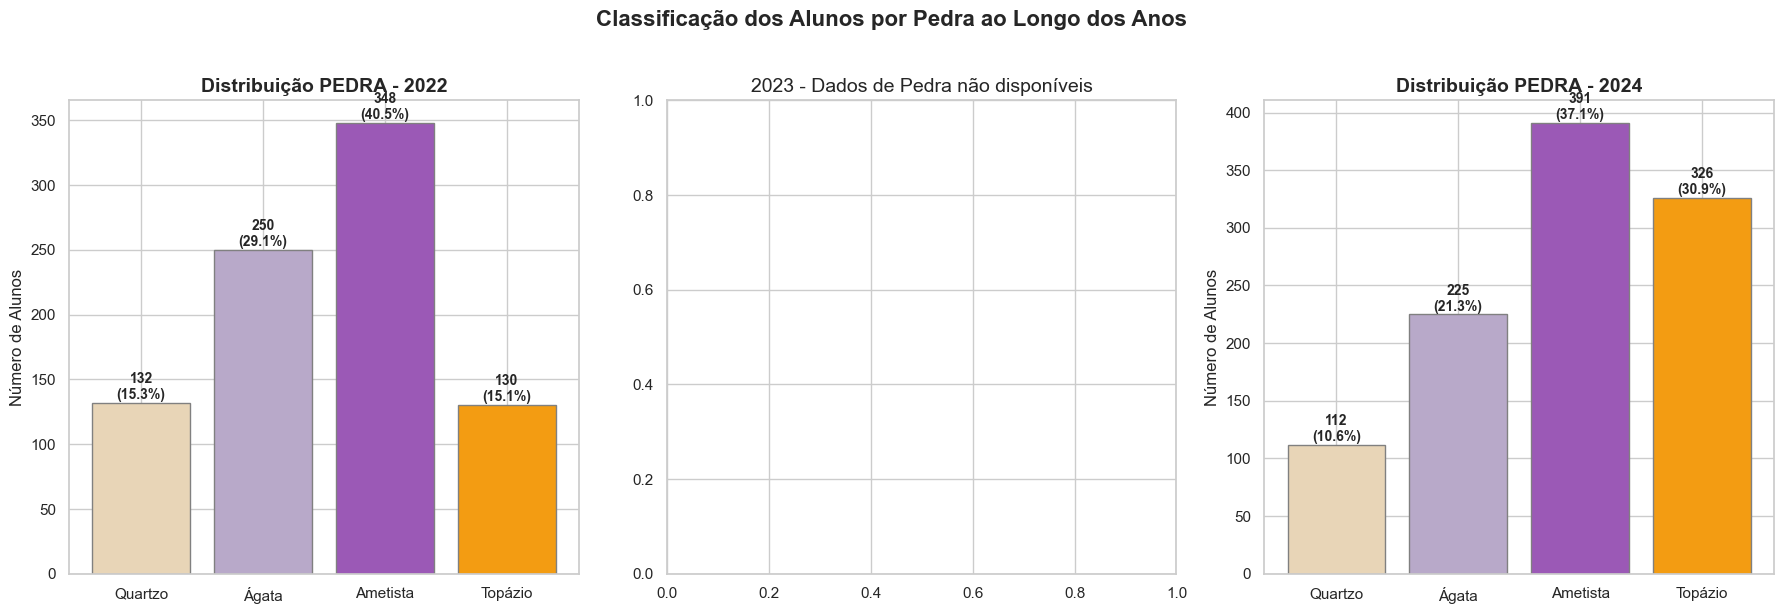

In [24]:
# Distribuição das Pedras ao longo dos anos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pedra_ordem = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']

for i, ano in enumerate([2022, 2023, 2024]):
    df_ano = df_consolidado[(df_consolidado['Ano'] == ano) & (df_consolidado['Pedra'].isin(pedra_ordem))]
    if len(df_ano) > 0:
        contagem = df_ano['Pedra'].value_counts()
        # Reindexar para manter ordem
        contagem = contagem.reindex(pedra_ordem).fillna(0)
        cores = [CORES_PEDRA.get(p, '#95a5a6') for p in contagem.index]
        bars = axes[i].bar(contagem.index, contagem.values, color=cores, edgecolor='gray')
        total = contagem.sum()
        for bar, val in zip(bars, contagem.values):
            if val > 0:
                axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                            f'{int(val)}\n({val/total*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
        axes[i].set_title(f'Distribuição PEDRA - {ano}', fontweight='bold')
        axes[i].set_ylabel('Número de Alunos')
    else:
        axes[i].set_title(f'{ano} - Dados de Pedra não disponíveis')

plt.suptitle('Classificação dos Alunos por Pedra ao Longo dos Anos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/17_pedra_evolucao.png', dpi=150, bbox_inches='tight')
plt.show()

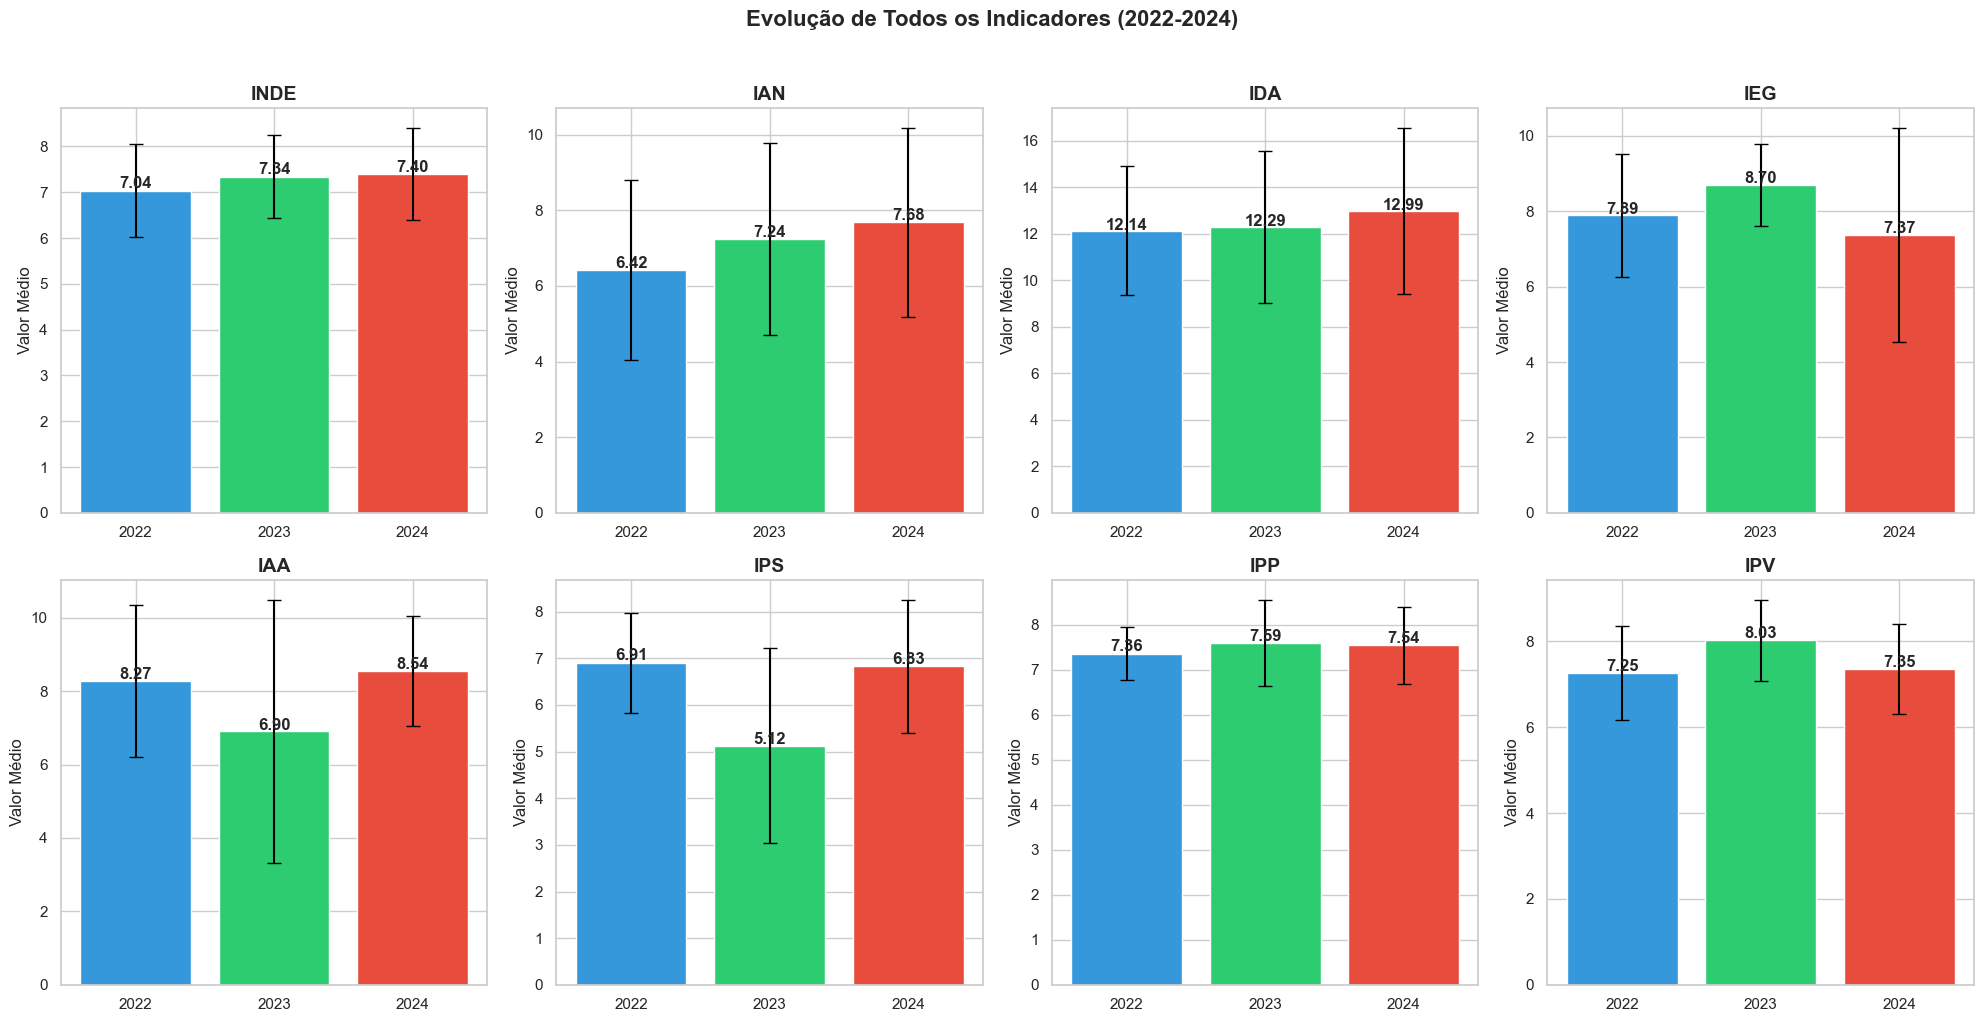

In [25]:
# Evolução dos indicadores médios por ano
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
indicadores_lista = ['INDE', 'IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']

for i, ind in enumerate(indicadores_lista):
    if i < len(axes):
        dados = df_consolidado.groupby('Ano')[ind].agg(['mean', 'std']).dropna()
        if len(dados) > 0:
            axes[i].bar(dados.index, dados['mean'], yerr=dados['std'], capsize=5,
                       color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white')
            for j, (ano, row) in enumerate(dados.iterrows()):
                axes[i].text(ano, row['mean'] + 0.05, f"{row['mean']:.2f}", ha='center', fontweight='bold')
            axes[i].set_title(f'{ind}', fontweight='bold')
            axes[i].set_xticks(dados.index)
            axes[i].set_ylabel('Valor Médio')

plt.suptitle('Evolução de Todos os Indicadores (2022-2024)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/18_evolucao_indicadores.png', dpi=150, bbox_inches='tight')
plt.show()

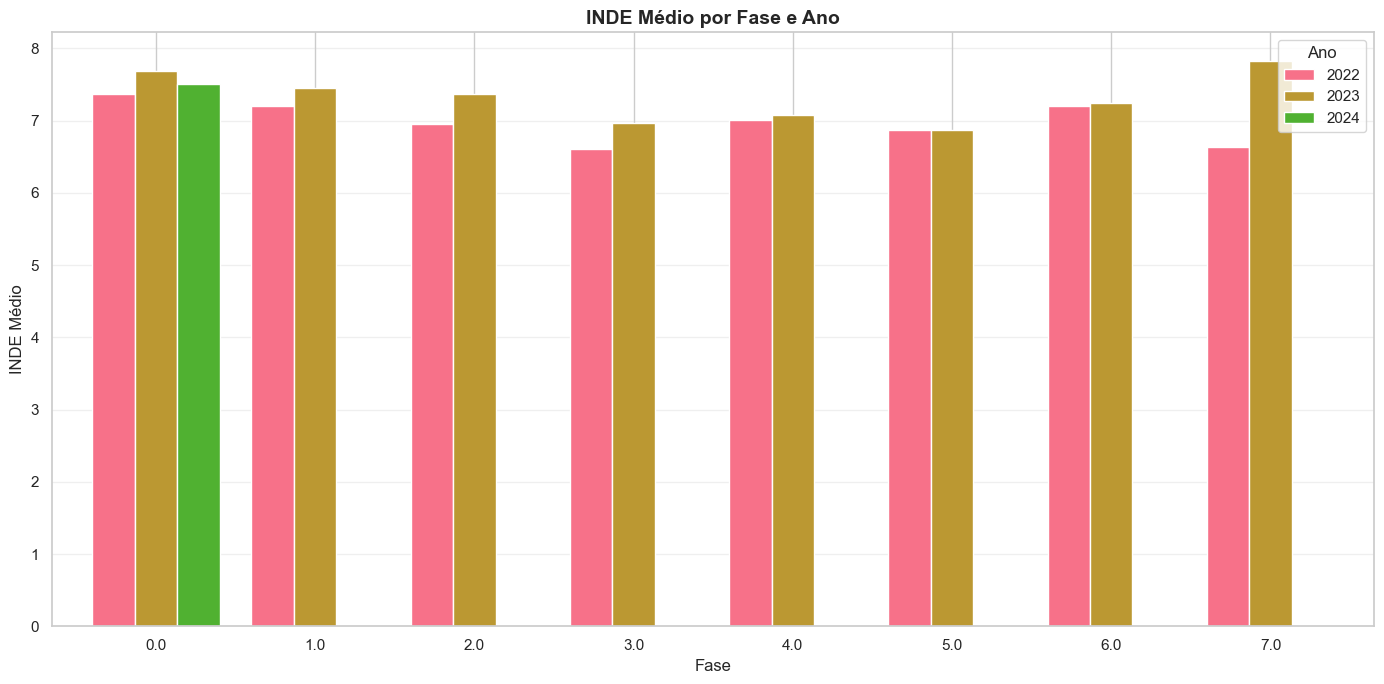

In [26]:
# INDE médio por Fase e Ano
fig, ax = plt.subplots(figsize=(14, 7))
df_fase_inde = df_consolidado.dropna(subset=['INDE', 'Fase']).copy()
df_fase_inde = df_fase_inde[df_fase_inde['Fase'].apply(lambda x: isinstance(x, (int, float)) and not np.isnan(x))]

pivot = df_fase_inde.groupby(['Ano', 'Fase'])['INDE'].mean().unstack(level=0)
pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.8)
ax.set_title('INDE Médio por Fase e Ano', fontweight='bold', fontsize=14)
ax.set_xlabel('Fase')
ax.set_ylabel('INDE Médio')
ax.legend(title='Ano')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/19_inde_por_fase_ano.png', dpi=150, bbox_inches='tight')
plt.show()

### Conclusão - Pergunta 10:
- A distribuição das Pedras mostra se os alunos estão migrando para classificações mais altas ao longo dos anos
- A evolução dos indicadores confirma (ou não) o impacto real do programa
- A análise por fase permite identificar onde o programa é mais efetivo

---
## Pergunta 11: Insights e Criatividade
**Análises adicionais e sugestões para a Passos Mágicos**

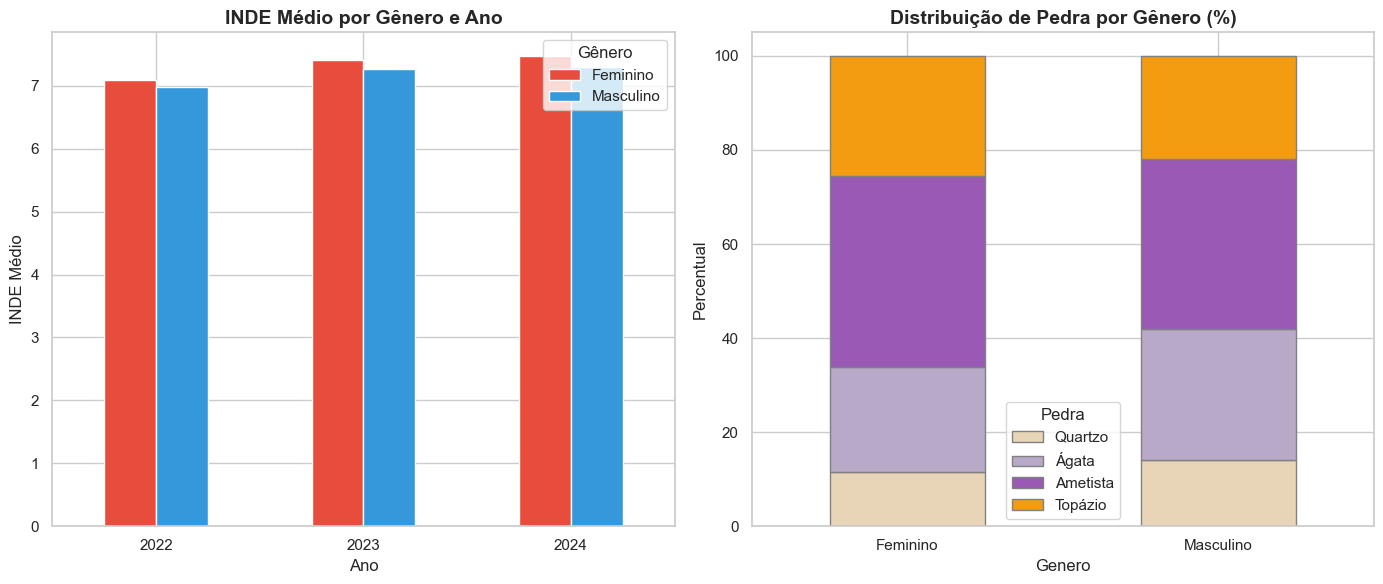

In [27]:
# Insight 1: Análise por Gênero
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df_genero = df_consolidado[df_consolidado['Genero'].isin(['Feminino', 'Masculino'])]

# INDE por gênero e ano
gen_inde = df_genero.groupby(['Ano', 'Genero'])['INDE'].mean().unstack()
gen_inde.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='white')
axes[0].set_title('INDE Médio por Gênero e Ano', fontweight='bold')
axes[0].set_ylabel('INDE Médio')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Gênero')

# Pedra por gênero
pedra_gen = df_genero[df_genero['Pedra'].isin(pedra_ordem)].groupby(['Genero', 'Pedra']).size().unstack(fill_value=0)
pedra_gen_pct = pedra_gen.div(pedra_gen.sum(axis=1), axis=0) * 100
pedra_gen_pct = pedra_gen_pct.reindex(columns=pedra_ordem)
pedra_gen_pct.plot(kind='bar', stacked=True, ax=axes[1],
                   color=[CORES_PEDRA.get(p, '#95a5a6') for p in pedra_ordem], edgecolor='gray')
axes[1].set_title('Distribuição de Pedra por Gênero (%)', fontweight='bold')
axes[1].set_ylabel('Percentual')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Pedra')

plt.tight_layout()
plt.savefig('../outputs/20_analise_genero.png', dpi=150, bbox_inches='tight')
plt.show()

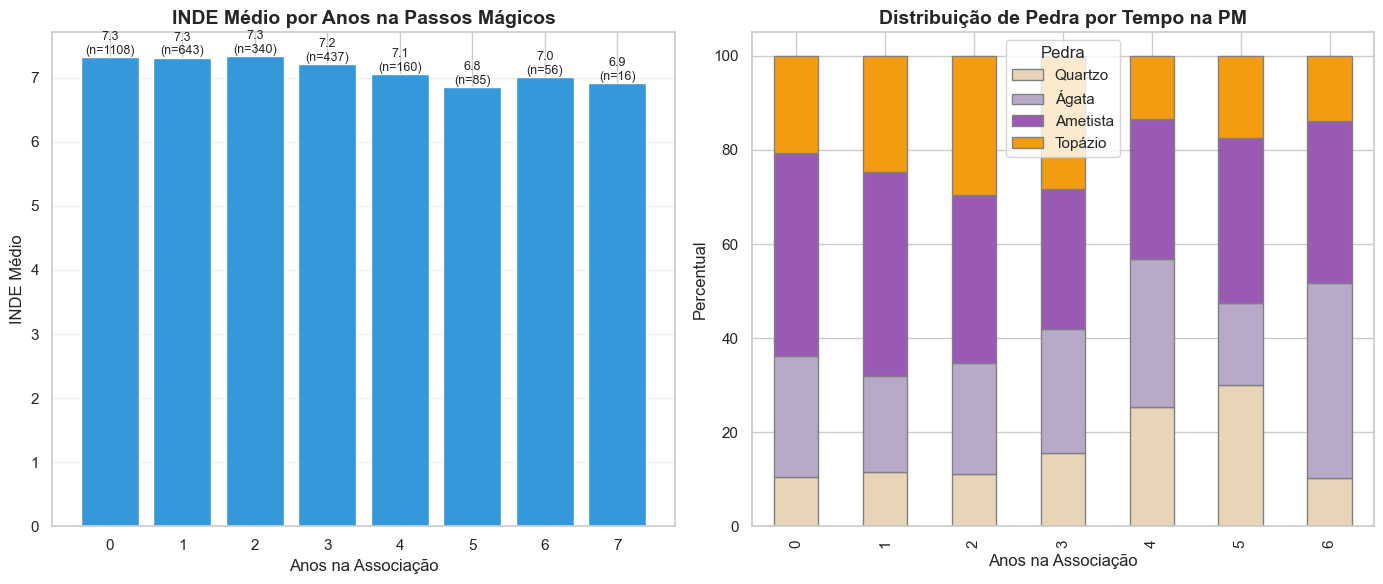

In [28]:
# Insight 2: Tempo na associação vs desempenho
if 'Ano_Ingresso' in df_consolidado.columns:
    df_tempo = df_consolidado.dropna(subset=['Ano_Ingresso', 'INDE']).copy()
    df_tempo['Anos_PM'] = df_tempo['Ano'] - df_tempo['Ano_Ingresso']
    df_tempo = df_tempo[df_tempo['Anos_PM'] >= 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # INDE por tempo na associação
    tempo_inde = df_tempo.groupby('Anos_PM')['INDE'].agg(['mean', 'count'])
    tempo_inde = tempo_inde[tempo_inde['count'] >= 10]  # Mínimo de 10 alunos

    axes[0].bar(tempo_inde.index, tempo_inde['mean'], color='#3498db', edgecolor='white')
    for j, (idx, row) in enumerate(tempo_inde.iterrows()):
        axes[0].text(idx, row['mean'] + 0.05, f"{row['mean']:.1f}\n(n={int(row['count'])})",
                    ha='center', fontsize=9)
    axes[0].set_title('INDE Médio por Anos na Passos Mágicos', fontweight='bold')
    axes[0].set_xlabel('Anos na Associação')
    axes[0].set_ylabel('INDE Médio')
    axes[0].grid(axis='y', alpha=0.3)

    # Pedra por tempo
    df_tempo_pedra = df_tempo[df_tempo['Pedra'].isin(pedra_ordem)]
    tempo_pedra = df_tempo_pedra.groupby(['Anos_PM', 'Pedra']).size().unstack(fill_value=0)
    tempo_pedra_pct = tempo_pedra.div(tempo_pedra.sum(axis=1), axis=0) * 100
    tempo_pedra_pct = tempo_pedra_pct.reindex(columns=pedra_ordem)
    tempo_pedra_pct.plot(kind='bar', stacked=True, ax=axes[1],
                         color=[CORES_PEDRA.get(p, '#95a5a6') for p in pedra_ordem], edgecolor='gray')
    axes[1].set_title('Distribuição de Pedra por Tempo na PM', fontweight='bold')
    axes[1].set_xlabel('Anos na Associação')
    axes[1].set_ylabel('Percentual')
    axes[1].legend(title='Pedra')

    plt.tight_layout()
    plt.savefig('../outputs/21_tempo_associacao.png', dpi=150, bbox_inches='tight')
    plt.show()

In [29]:
# Insight 3: Análise por Instituição de Ensino
if 'Instituicao' in df_consolidado.columns:
    df_inst = df_consolidado.dropna(subset=['Instituicao', 'INDE'])

    fig, ax = plt.subplots(figsize=(12, 6))
    inst_inde = df_inst.groupby('Instituicao')['INDE'].agg(['mean', 'count', 'std'])
    inst_inde = inst_inde[inst_inde['count'] >= 20].sort_values('mean', ascending=True)

    bars = ax.barh(range(len(inst_inde)), inst_inde['mean'],
                   xerr=inst_inde['std'], capsize=3,
                   color=plt.cm.viridis(np.linspace(0.2, 0.8, len(inst_inde))), edgecolor='white')
    ax.set_yticks(range(len(inst_inde)))
    ax.set_yticklabels(inst_inde.index)
    ax.set_xlabel('INDE Médio')
    ax.set_title('INDE Médio por Instituição de Ensino', fontweight='bold')
    for i, (idx, row) in enumerate(inst_inde.iterrows()):
        ax.text(row['mean'] + 0.05, i, f"{row['mean']:.2f} (n={int(row['count'])})", va='center')

    plt.tight_layout()
    plt.savefig('../outputs/22_instituicao_inde.png', dpi=150, bbox_inches='tight')
    plt.show()

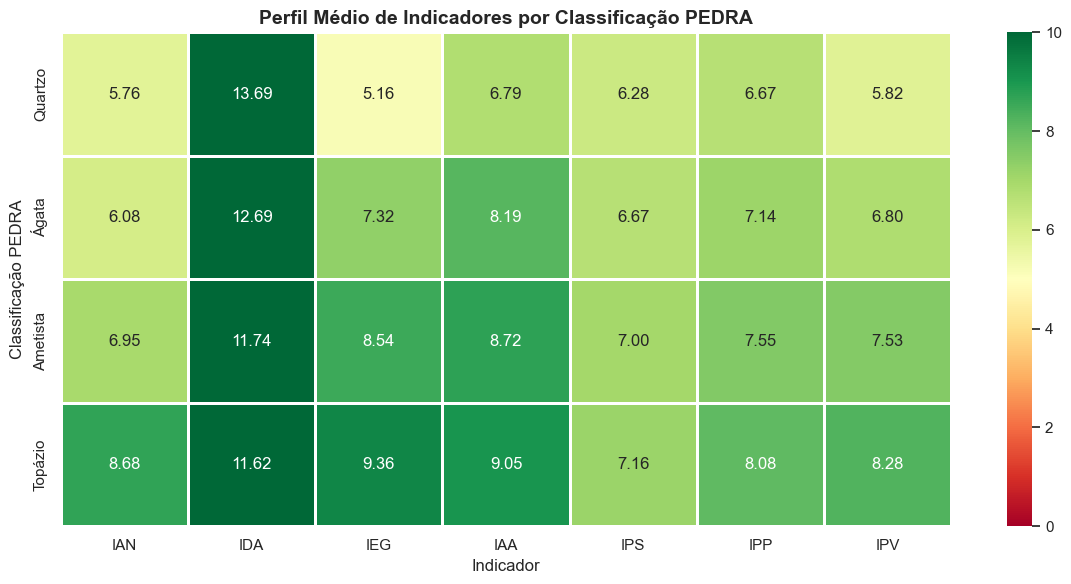

In [30]:
# Insight 4: Heatmap de indicadores por Pedra
fig, ax = plt.subplots(figsize=(12, 6))
df_pedra_ind = df_consolidado[df_consolidado['Pedra'].isin(pedra_ordem)]
heatmap_data = df_pedra_ind.groupby('Pedra')[['IAN', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV']].mean()
heatmap_data = heatmap_data.reindex(pedra_ordem)

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=1, ax=ax, vmin=0, vmax=10)
ax.set_title('Perfil Médio de Indicadores por Classificação PEDRA', fontweight='bold', fontsize=14)
ax.set_ylabel('Classificação PEDRA')
ax.set_xlabel('Indicador')
plt.tight_layout()
plt.savefig('../outputs/23_heatmap_pedra.png', dpi=150, bbox_inches='tight')
plt.show()

### Sugestões para a Passos Mágicos:

1. **Sistema de Alerta Precoce**: Implementar monitoramento contínuo dos indicadores IPS e IEG para identificar alunos em risco antes que a queda de desempenho se materialize.

2. **Intervenções Diferenciadas por Perfil**: Usar a análise de clusters para personalizar as intervenções pedagógicas e psicológicas com base no perfil de cada aluno.

3. **Foco na Autoavaliação**: Trabalhar a autopercepção dos alunos com discrepância entre IAA e IDA, promovendo autoconhecimento mais realista.

4. **Mentoria por Pares**: Alunos classificados como Topázio podem servir como mentores para alunos Quartzo, fortalecendo engajamento e aprendizado.

5. **Acompanhamento Longitudinal**: Rastrear a trajetória individual dos alunos ao longo dos anos para medir o impacto de longo prazo do programa.

---
## Exportar dados limpos para o modelo preditivo

In [31]:
# Salvar dados consolidados para uso no modelo preditivo
df_consolidado.to_csv('../data_consolidado.csv', index=False)
print(f"Dados consolidados salvos: {df_consolidado.shape}")
print(f"\nResumo final:")
print(f"  Total de registros: {len(df_consolidado)}")
print(f"  Anos: {sorted(df_consolidado['Ano'].unique())}")
print(f"  Indicadores com dados: {df_consolidado[['INDE','IAN','IDA','IEG','IAA','IPS','IPP','IPV']].notna().sum().to_dict()}")
print("\nAnálise exploratória concluída com sucesso!")

Dados consolidados salvos: (3030, 17)

Resumo final:
  Total de registros: 3030
  Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
  Indicadores com dados: {'INDE': 2845, 'IAN': 3030, 'IDA': 2631, 'IEG': 2954, 'IAA': 2865, 'IPS': 2859, 'IPP': 3030, 'IPV': 2852}

Análise exploratória concluída com sucesso!
